## Ortec Case Study

In [2]:
#IMPORTS
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import polars as pl 
import matplotlib.pyplot as plt 
import seaborn as sns
import bambi as bmb
import pymc as pm
import arviz as az
import networkx as nx

import time
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
DATA = Path("DATA")

In [4]:
df = pd.read_csv(DATA / "ESG_Dataset.csv")

/var/folders/k_/0twp8_5j5790tr9j876ygj840000gn/T/ipykernel_19670/3689774604.py:1: DtypeWarning: Columns (0: DeckingType, 1: Kitchen, 2: DeckingExtras) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA / "ESG_Dataset.csv")


In [5]:
df.head(20)

,ReservableOptionMarketGroupId,WeekBeforeArrival,WeekStartDate,MarketGroupCode,BrandGroupCode,CampsiteCode,AccoKindCode,AccoTypeRangeCode,SpecialPeriodCode,SeasonalCluster,...,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
0,Domestic-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,20,234,0,35.2708,22.4478,12.0
1,DACH-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0
2,Benelux-Thundurus-Meditite-Mobile-2024-01-01,52,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,32,234,0,35.2708,22.4478,12.0
3,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,52,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
4,Domestic-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
5,DACH-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,3,0,63,234,0,35.2708,22.4478,12.0
6,Benelux-Thundurus-Meditite-Mobile-2024-01-01,51,2024-01-01,Benelux,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,1,0,32,234,0,35.2708,22.4478,12.0
7,Rest of Europe-Thundurus-Meditite-Mobile-2024-...,51,2024-01-01,Rest of Europe,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,17,234,0,35.2708,22.4478,12.0
8,Domestic-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,Domestic,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,0,0,20,234,0,35.2708,22.4478,12.0
9,DACH-Thundurus-Meditite-Mobile-2024-01-01,50,2024-01-01,DACH,Thundurus,Meditite,Mobile,Comfort,Festival of Arceus,Perrserker,...,145.38,0.0,2,0,63,234,0,35.2708,22.4478,12.0


In [6]:
df.describe()

,WeekBeforeArrival,Airco,Bedrooms,HotTub,Tropical,Bathrooms,Sleeps,TV,ArrivalMonth,DiscountedPrice,DiscountedPriceLastYear,HistoricalBookedNights,HistoricalBookedNightsLastYear,TotalBookedNights,Capacity,CapacityLastYear,latitude,longitude,AvgTemperature
count,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3130816.0,3.130816e+06,3.130816e+06,3.130816e+06
mean,2.600000e+01,3.098592e-01,2.007042e+00,1.126761e-01,2.183099e-01,1.415493e+00,3.413310e+02,4.929577e-01,6.490385e+00,2.126906e+02,0.0,9.321742e-01,0.0,4.940523e+01,3.465669e+02,0.0,4.833767e+01,7.217771e+00,1.253713e+01
std,1.529706e+01,4.624354e-01,1.010484e+00,3.161964e-01,4.130989e-01,6.307046e-01,1.549068e+02,4.999505e-01,3.447394e+00,1.323063e+02,0.0,2.338494e+00,0.0,5.668432e+01,1.591119e+02,0.0,8.719626e+00,1.029888e+01,7.502503e+00
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.050000e+02,0.000000e+00,1.000000e+00,4.206000e+01,0.0,0.000000e+00,0.0,0.000000e+00,1.050000e+02,0.0,3.344880e+01,-6.975400e+00,-3.500000e+00
25%,1.300000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.210000e+02,0.000000e+00,3.750000e+00,1.071175e+02,0.0,0.000000e+00,0.0,8.000000e+00,2.280000e+02,0.0,4.073920e+01,-2.146300e+00,6.800000e+00
50%,2.600000e+01,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.205000e+02,0.000000e+00,6.500000e+00,1.843400e+02,0.0,0.000000e+00,0.0,3.100000e+01,3.240000e+02,0.0,4.809790e+01,5.509600e+00,1.250000e+01
75%,3.900000e+01,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.290000e+02,1.000000e+00,9.000000e+00,2.737900e+02,0.0,1.000000e+00,0.0,7.100000e+01,4.350000e+02,0.0,5.748670e+01,1.756240e+01,1.750000e+01
max,5.200000e+01,1.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,9.500000e+02,1.000000e+00,1.200000e+01,6.650600e+02,0.0,1.330000e+02,0.0,5.650000e+02,9.500000e+02,0.0,6.232910e+01,2.619230e+01,2.800000e+01


# Model choice

We want to optimize pricing, the only free variable we have, to maximize revenue, with capacity as the main constraint. We can derive features from the other columns.

We choose, initially, to use a multilevel model, because the data is hierarchically structured (campsites nested in regions in countries, crossed with markets), most groups have too little data to estimate elasticities independently, so the case explicitly requires a defensible cold-start procedure, and the pricing decision is per-group - partial pooling addresses all four simultaneously while delivering a posterior that drives the human in the loop story

First, let's do some EDA to get an idea of what we're dealing with

In [ ]:
#Data integrity
identity = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate"], observed=True)
              .agg(HBN_sum=("HistoricalBookedNights", "sum"),
                   TBN_first=("TotalBookedNights", "first"),
                   TBN_nunique=("TotalBookedNights", "nunique")))
identity["diff"] = identity["HBN_sum"] - identity["TBN_first"]
print(f"ROMGIDs with constant TBN across snapshots:  {(identity['TBN_nunique'] == 1).all()}")
print(f"TBN == sum(HBN) holds for all ROMGIDs:       {(identity['diff'] == 0).all()}")
print(f"Total ROMGIDs checked: {len(identity):,}")

#LastYear columns: confirm all-zero → drop ===
ly_cols = ["DiscountedPriceLastYear", "HistoricalBookedNightsLastYear", "CapacityLastYear"]
print("\nLastYear columns — max value (expect 0):")
print(df[ly_cols].max())

# Redundancy: AccoKind vs AccommodationType, AccoTypeRange vs AccommodationRange ===
print("\nAccoKindCode × AccommodationType (1:1 means drop one):")
print(pd.crosstab(df["AccoKindCode"], df["AccommodationType"]))
print("\nAccoTypeRangeCode × AccommodationRange:")
print(pd.crosstab(df["AccoTypeRangeCode"], df["AccommodationRange"]))


ROMGIDs with constant TBN across snapshots:  True
TBN == sum(HBN) holds for all ROMGIDs:       True
Total ROMGIDs checked: 59,072

LastYear columns — max value (expect 0):
DiscountedPriceLastYear           0.0
HistoricalBookedNightsLastYear    0.0
CapacityLastYear                  0.0
dtype: float64

AccoKindCode × AccommodationType (1:1 means drop one):
AccommodationType  All-Inclusive   Basic  Self-Catering  Serviced
AccoKindCode                                                     
Mobile                    308672  220480         198432    132288
Permanent                 110240  220480         154336    330720
Seasonal                  132288  220480         154336    154336
Static                    176384  220480         220480    176384

AccoTypeRangeCode × AccommodationRange:
AccommodationRange  Budget     Mid  Premium
AccoTypeRangeCode                          
Comfort             242528  286624   132288
Family              176384  220480   110240
Luxury              330720  30

AccomodationType and AccommodationRange should be fixed effects, adding them as random effects would make the groups too small

In [9]:
cat_cols = ["MarketGroupCode", "BrandGroupCode", "CampsiteCode", "AccoKindCode",
            "AccoTypeRangeCode", "SpecialPeriodCode", "SeasonalCluster", "CampsiteCluster",
            "CampsiteCountry", "CampsiteRegion", "CampsiteType",
            "AccommodationType", "AccommodationRange",
            "DeckingType", "Roof", "Kitchen", "DeckingExtras"]

print("Unique values per categorical column:")
print(df[cat_cols].nunique().sort_values())

print("\nSpecialPeriodCode value counts:")
print(df["SpecialPeriodCode"].value_counts(dropna=False))

print("\nMissingness % per column (non-zero only):")
miss = df.isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(2))


Unique values per categorical column:
AccommodationRange      3
MarketGroupCode         4
DeckingType             4
AccoKindCode            4
AccommodationType       4
Kitchen                 4
Roof                    5
DeckingExtras           5
AccoTypeRangeCode       5
CampsiteType            8
CampsiteCountry         8
SpecialPeriodCode       9
CampsiteRegion         10
SeasonalCluster       142
CampsiteCode          142
BrandGroupCode        142
CampsiteCluster       142
dtype: int64

SpecialPeriodCode value counts:
SpecialPeriodCode
Sunny Castform Season    722496
Glaceon's Rest           602080
Standard Week            421456
Shaymin Bloom            421456
Togepi Celebration       240832
Haunter's Eve            240832
Festival of Arceus       180624
Delibird's Gift Week     180624
Harvest Trevenant        120416
Name: count, dtype: int64

Missingness % per column (non-zero only):
DeckingExtras    22.54
Kitchen          21.13
DeckingType      17.61
dtype: float64


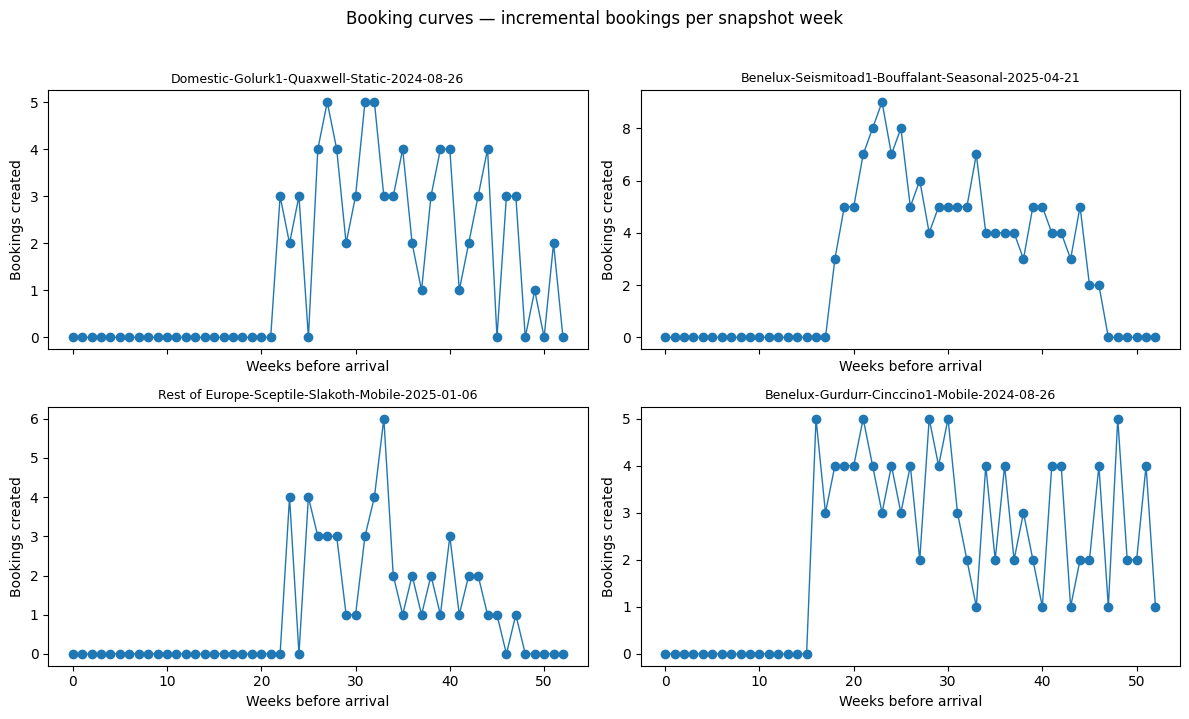

In [8]:


# Pick 4 non-empty ROMGIDs at random for variety
sample_keys = (df.groupby("ReservableOptionMarketGroupId")["TotalBookedNights"]
                 .first()
                 .pipe(lambda s: s[s > 50])
                 .sample(4, random_state=42).index)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, key in zip(axes.flat, sample_keys):
    sub = (df[df["ReservableOptionMarketGroupId"] == key]
             .sort_values("WeekBeforeArrival", ascending=False))
    ax.plot(sub["WeekBeforeArrival"], sub["HistoricalBookedNights"], marker="o", lw=1)
    ax.set_title(key, fontsize=9)
    ax.invert_xaxis()
    ax.set_xlabel("Weeks before arrival"); ax.set_ylabel("Bookings created")
fig.suptitle("Booking curves — incremental bookings per snapshot week", y=1.02)
fig.tight_layout(); plt.show()


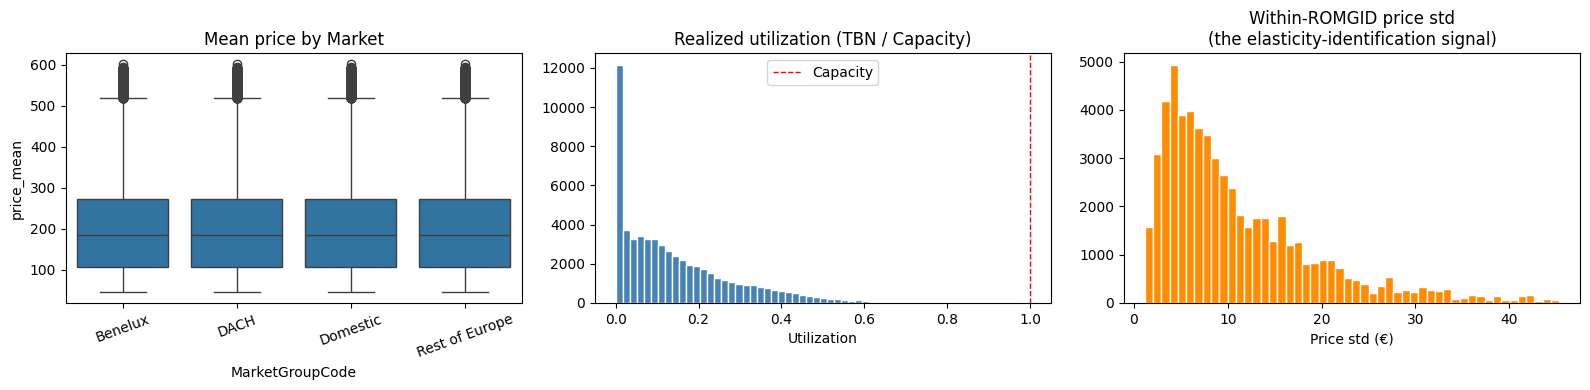

Median utilization:                        10.47%
% ROMGIDs near capacity (>=90% util):      0.00%
Median within-ROMGID price std:            €8.46
% ROMGIDs with any price variation:        100.00%


In [9]:


# ROMGID-level summary
romgid = (df.groupby(["ReservableOptionMarketGroupId", "WeekStartDate", "MarketGroupCode",
                      "AccoKindCode", "CampsiteCountry"], observed=True)
            .agg(price_mean=("DiscountedPrice", "mean"),
                 price_std=("DiscountedPrice", "std"),
                 TBN=("TotalBookedNights", "first"),
                 Cap=("Capacity", "first"))
            .reset_index())
romgid["utilization"] = romgid["TBN"] / romgid["Cap"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=romgid, x="MarketGroupCode", y="price_mean", ax=axes[0])
axes[0].set_title("Mean price by Market")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(romgid["utilization"], bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(1.0, color="red", lw=1, ls="--", label="Capacity")
axes[1].set_title("Realized utilization (TBN / Capacity)")
axes[1].set_xlabel("Utilization"); axes[1].legend()

axes[2].hist(romgid["price_std"].dropna(), bins=50, color="darkorange", edgecolor="white")
axes[2].set_title("Within-ROMGID price std\n(the elasticity-identification signal)")
axes[2].set_xlabel("Price std (€)")

fig.tight_layout(); plt.show()

print(f"Median utilization:                        {romgid['utilization'].median():.2%}")
print(f"% ROMGIDs near capacity (>=90% util):      {(romgid['utilization'] >= 0.9).mean():.2%}")
print(f"Median within-ROMGID price std:            €{romgid['price_std'].median():.2f}")
print(f"% ROMGIDs with any price variation:        {(romgid['price_std'] > 0).mean():.2%}")


In [10]:
#Features
# drop unusable columns
df = df.drop(columns=["DiscountedPriceLastYear",
                      "HistoricalBookedNightsLastYear",
                      "CapacityLastYear"])

# Rename price + derive log_price
df = df.rename(columns={"DiscountedPrice": "price"})
df["log_price"] = np.log(df["price"])
df["log_capacity"] = np.log(df["Capacity"])

# Special-period encoding
df["is_special"] = (df["SpecialPeriodCode"] != "Standard Week").astype(int)

# Time features
df["WeekStartDate"] = pd.to_datetime(df["WeekStartDate"])
df["iso_week"] = df["WeekStartDate"].dt.isocalendar().week.astype(int)
df["year"] = df["WeekStartDate"].dt.year

#Impute missing categoricals as "Missing"
for col in ["DeckingExtras", "Kitchen", "DeckingType"]:
    df[col] = df[col].fillna("Missing")

# Group key for the per-group elasticity (~568 groups)
df["group_key"] = (df["CampsiteCode"].astype(str) + "_"
                   + df["AccoKindCode"].astype(str) + "_"
                   + df["AccoTypeRangeCode"].astype(str) + "_"
                   + df["MarketGroupCode"].astype(str))

print(f"Final shape: {df.shape}")
print(f"# distinct group keys (per-group elasticity targets): {df['group_key'].nunique():,}")
print(f"# distinct campsites: {df['CampsiteCode'].nunique()}")
print(f"# distinct regions: {df['CampsiteRegion'].nunique()}")
print(f"# distinct countries: {df['CampsiteCountry'].nunique()}")
print(f"\nNew columns added: log_price, log_capacity, is_special, iso_week, year, group_key")
df[["price","log_price","is_special","iso_week","year","group_key"]].head()


Final shape: (3130816, 41)
# distinct group keys (per-group elasticity targets): 568
# distinct campsites: 142
# distinct regions: 10
# distinct countries: 8

New columns added: log_price, log_capacity, is_special, iso_week, year, group_key


,price,log_price,is_special,iso_week,year,group_key
0,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic
1,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_DACH
2,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Benelux
3,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Rest of Europe
4,145.38,4.979351,1,1,2024,Meditite_Mobile_Comfort_Domestic


In [11]:

# 1. Sample — stratify so every group has at least some rows
sample_n = 50_000
df_sample = (df.sample(n=sample_n, random_state=RANDOM_SEED)
               .reset_index(drop=True))

# Need group_key as categorical for bambi
df_sample["group_key"] = df_sample["group_key"].astype("category")
df_sample["AccommodationType"] = df_sample["AccommodationType"].astype("category")
df_sample["AccommodationRange"] = df_sample["AccommodationRange"].astype("category")

print(f"Sample size:       {sample_n:,} rows ({sample_n/len(df)*100:.1f}% of full data)")
print(f"Groups in sample:  {df_sample['group_key'].nunique()} / 568")

# 2. Minimal viable formula — elasticity backbone + a couple of fixed effects
formula = (
    "HistoricalBookedNights ~ "
    "log_price + is_special + log_capacity + AccommodationType + AccommodationRange + "
    "(1 + log_price | group_key)"           # per-group intercept + elasticity
)

# 3. Build model — Negative Binomial likelihood (handles overdispersion + zero-rich data)
model = bmb.Model(formula, data=df_sample, family="negativebinomial")
model.build()
print(model)


Sample size:       50,000 rows (1.6% of full data)
Groups in sample:  568 / 568
       Formula: HistoricalBookedNights ~ log_price + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 38.4026)
            log_price ~ Normal(mu: 0.0, sigma: 3.872)
            is_special ~ Normal(mu: 0.0, sigma: 7.3218)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5558)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5525 5.9043 5.7441])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1273 6.2123])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 38.4026))
            log_price|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 3.872))
        
        Auxiliary parameters
      

In [14]:
# === Fit with NUTS (modest settings for the pilot) ===
import time
t0 = time.time()
idata = model.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.9,
    random_seed=RANDOM_SEED,
)
print(f"\nFit time: {(time.time()-t0)/60:.1f} min")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, is_special, log_capacity, AccommodationType, AccommodationRange, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 219 seconds.
There were 41 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Fit time: 3.7 min


In [15]:
# === Convergence diagnostics ===
summary = az.summary(idata, var_names=["log_price", "is_special",
                                        "log_capacity", "Intercept"])
print("Global fixed-effect summary:")
print(summary)

print(f"\nMax R-hat (should be < 1.05):   {az.summary(idata)['r_hat'].max():.3f}")
print(f"Min ESS (should be > 100):       {az.summary(idata)['ess_bulk'].min():.0f}")

# === The headline number: global elasticity ===
log_price_post = idata.posterior["log_price"].values.flatten()
print(f"\nGlobal elasticity β (log_price coef):")
print(f"  Mean:    {log_price_post.mean():.3f}")
print(f"  80% CI:  ({np.percentile(log_price_post,10):.3f}, {np.percentile(log_price_post,90):.3f})")
print(f"  P(β<0):  {(log_price_post < 0).mean():.1%}    ← should be ~100%")


Global fixed-effect summary:
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_price     0.294  0.096   0.133    0.487      0.005    0.004     348.0   
is_special    0.647  0.033   0.590    0.704      0.001    0.001    1383.0   
log_capacity  0.986  0.084   0.839    1.150      0.005    0.003     293.0   
Intercept    -7.997  0.681  -9.371   -6.773      0.041    0.023     284.0   

              ess_tail  r_hat  
log_price        356.0   1.00  
is_special       739.0   1.00  
log_capacity     488.0   1.01  
Intercept        343.0   1.00  

Max R-hat (should be < 1.05):   1.180
Min ESS (should be > 100):       8

Global elasticity β (log_price coef):
  Mean:    0.294
  80% CI:  (0.176, 0.423)
  P(β<0):  0.1%    ← should be ~100%


This model looks wrong... It's saying higher prices lead to more bookings. This is economically very unlikely. It's also not a sampling problem, as all the Rhats are fine. The reason might be that ORTEC's dynamic pricer raises the price, week over week you see that when price went up, bookings also went up, a naive regression interprets this as "price causes demand", but it's actually demand causing price. This is a classic problem with estimating price elasticity from non experimental pricing data. Both between group and within group variation are endogenous, our Bayesian model can't fix what's fundamentally an identification problem. This information is useful though, and we should consider how we deal with it.

Group-level elasticity distribution:
  Mean:        +0.000
  Median:      +0.000
  % negative:  48.9%
  % positive:  51.1%


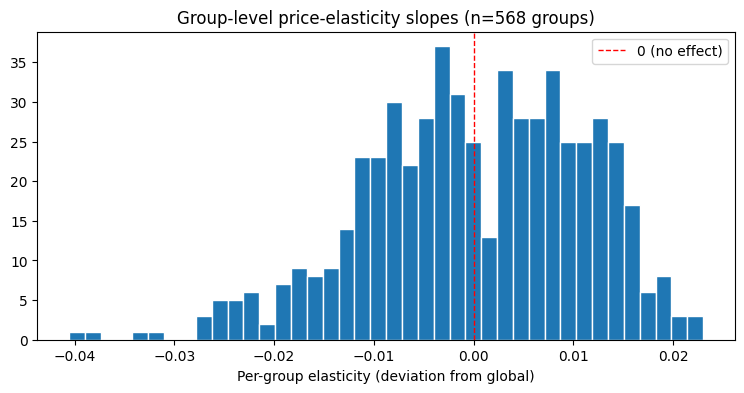

In [16]:
# Distribution of per-group elasticities (log_price slope)
group_slopes = (idata.posterior["log_price|group_key"]
                  .mean(dim=["chain","draw"])
                  .values)

print(f"Group-level elasticity distribution:")
print(f"  Mean:        {group_slopes.mean():+.3f}")
print(f"  Median:      {np.median(group_slopes):+.3f}")
print(f"  % negative:  {(group_slopes < 0).mean():.1%}")
print(f"  % positive:  {(group_slopes > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(group_slopes, bins=40, edgecolor="white")
ax.axvline(0, color="red", lw=1, ls="--", label="0 (no effect)")
ax.set_xlabel("Per-group elasticity (deviation from global)")
ax.set_title(f"Group-level price-elasticity slopes (n={len(group_slopes)} groups)")
ax.legend()
plt.show()


Not very informative... We should restructure, we have an identification problem, let's specify DAG's to actually specify the causal structure of price changes on bookings.

In [14]:
#We construct bookings on books, the demand signal the pricer reacts to
df = df.sort_values(
    ["ReservableOptionMarketGroupId", "WeekStartDate", "WeekBeforeArrival"],
    ascending=[True, True, False]   # WBA descending: 52 → 0 = time flowing forward
)

group_cols = ["ReservableOptionMarketGroupId", "WeekStartDate"]
df["bookings_on_books"] = (
    df.groupby(group_cols)["HistoricalBookedNights"]
      .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# Log scale (these can grow large; log keeps the linear predictor reasonable)
df["log_bob"] = np.log1p(df["bookings_on_books"])

print("bookings_on_books distribution:")
print(df["bookings_on_books"].describe())
print(f"\n% rows with bookings_on_books > 0: {(df['bookings_on_books'] > 0).mean():.1%}")
df[["ReservableOptionMarketGroupId","WeekStartDate","WeekBeforeArrival",
    "HistoricalBookedNights","bookings_on_books"]].head(10)


bookings_on_books distribution:
count    3.130816e+06
mean     2.811315e+01
std      4.505879e+01
min      0.000000e+00
25%      0.000000e+00
50%      9.000000e+00
75%      3.700000e+01
max      5.650000e+02
Name: bookings_on_books, dtype: float64

% rows with bookings_on_books > 0: 74.0%


,ReservableOptionMarketGroupId,WeekStartDate,WeekBeforeArrival,HistoricalBookedNights,bookings_on_books
2954434,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,52,3,0.0
2954438,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,51,6,3.0
2954442,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,50,8,9.0
2954446,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,49,6,17.0
2954450,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,48,5,23.0
2954454,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,47,5,28.0
2954458,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,46,4,33.0
2954462,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,45,3,37.0
2954466,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,44,4,40.0
2954470,Benelux-Amoonguss1-Milcery-Permanent-2024-01-01,2024-01-01,43,8,44.0


We refit with log_bob in the conditioning set, no forced strong priors.

In [15]:
# Re-sample (need the new column in the sample)
df_sample = df.sample(n=50_000, random_state=RANDOM_SEED).reset_index(drop=True)
for col in ["group_key", "AccommodationType", "AccommodationRange"]:
    df_sample[col] = df_sample[col].astype("category")

formula_v3 = (
    "HistoricalBookedNights ~ "
    "log_price + log_bob + is_special + log_capacity + "
    "AccommodationType + AccommodationRange + "
    "(1 + log_price | group_key)"
)

model_v3 = bmb.Model(formula_v3, data=df_sample, family="negativebinomial")
model_v3.build()
print(model_v3)


       Formula: HistoricalBookedNights ~ log_price + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 38.6654)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 38.6654))
            log_price|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 3.8806))
        
        Auxiliary parameters
            alpha ~ H

In [19]:


t0 = time.time()
idata_v3 = model_v3.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
)
print(f"Fit time: {(time.time()-t0)/60:.1f} min\n")

# Convergence
summary_v3 = az.summary(idata_v3,
    var_names=["log_price", "log_bob", "is_special", "log_capacity", "Intercept"])
print(summary_v3)

# Headline elasticity check
logp = idata_v3.posterior["log_price"].values.flatten()
print(f"\nGlobal price elasticity β (with bookings_on_books in conditioning set):")
print(f"  Mean:    {logp.mean():+.3f}")
print(f"  80% CI:  ({np.percentile(logp,10):+.3f}, {np.percentile(logp,90):+.3f})")
print(f"  P(β<0):  {(logp < 0).mean():.1%}")

logbob = idata_v3.posterior["log_bob"].values.flatten()
print(f"\nlog_bob coefficient (the demand-autocorrelation channel):")
print(f"  Mean:    {logbob.mean():+.3f}    (positive expected — high prior bookings → high current bookings)")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, log_bob, is_special, log_capacity, AccommodationType, AccommodationRange, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 182 seconds.
There were 44 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fit time: 3.1 min

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_price    -0.752  0.090  -0.921   -0.584      0.005    0.003     313.0   
log_bob       0.453  0.007   0.439    0.466      0.000    0.000    1348.0   
is_special    0.436  0.030   0.383    0.494      0.001    0.002    1791.0   
log_capacity  0.582  0.063   0.452    0.686      0.003    0.002     473.0   
Intercept    -1.917  0.550  -2.988   -0.948      0.030    0.018     339.0   

              ess_tail  r_hat  
log_price        344.0   1.00  
log_bob          681.0   1.00  
is_special       424.0   1.01  
log_capacity     563.0   1.01  
Intercept        474.0   1.01  

Global price elasticity β (with bookings_on_books in conditioning set):
  Mean:    -0.752
  80% CI:  (-0.864, -0.638)
  P(β<0):  100.0%

log_bob coefficient (the demand-autocorrelation channel):
  Mean:    +0.453    (positive expected — high prior bookings → high current bookings)


Global elasticity:         -0.752
Per-group deviation SD:    0.006
Per-group absolute β:
  range:                   [-0.770, -0.736]
  median:                  -0.752
  % with β > 0 (gate):     0.0%   (should be < 5%)


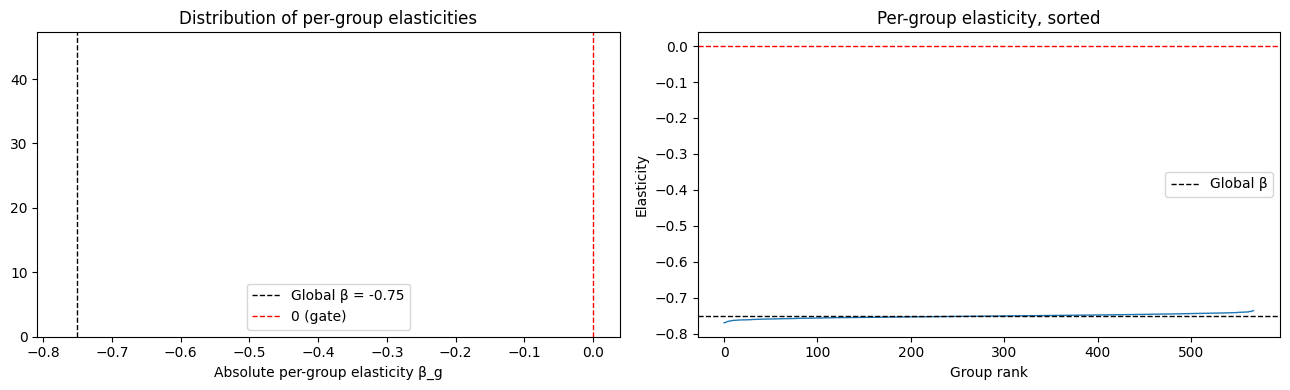

In [20]:
# === Per-group elasticity distribution (after DAG fix) ===
group_dev = (idata_v3.posterior["log_price|group_key"]
               .mean(dim=["chain","draw"])
               .values)
global_beta = idata_v3.posterior["log_price"].mean().item()
group_abs = global_beta + group_dev   # absolute per-group elasticity

print(f"Global elasticity:         {global_beta:+.3f}")
print(f"Per-group deviation SD:    {group_dev.std():.3f}")
print(f"Per-group absolute β:")
print(f"  range:                   [{group_abs.min():+.3f}, {group_abs.max():+.3f}]")
print(f"  median:                  {np.median(group_abs):+.3f}")
print(f"  % with β > 0 (gate):     {(group_abs > 0).mean():.1%}   (should be < 5%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(group_abs, bins=40, edgecolor="white", color="steelblue")
axes[0].axvline(global_beta, color="black", lw=1, ls="--", label=f"Global β = {global_beta:.2f}")
axes[0].axvline(0, color="red", lw=1, ls="--", label="0 (gate)")
axes[0].set_xlabel("Absolute per-group elasticity β_g")
axes[0].set_title("Distribution of per-group elasticities")
axes[0].legend()

# Sort + plot for visual heterogeneity check
order = np.argsort(group_abs)
axes[1].plot(np.arange(len(group_abs)), group_abs[order], lw=1)
axes[1].axhline(global_beta, color="black", lw=1, ls="--", label="Global β")
axes[1].axhline(0, color="red", lw=1, ls="--")
axes[1].set_xlabel("Group rank")
axes[1].set_ylabel("Elasticity")
axes[1].set_title("Per-group elasticity, sorted")
axes[1].legend()

plt.tight_layout(); plt.show()


The random slope is doing almost 0 work, a single global elasticity is the right model for this dataset. Still, we should keep (1+ log_price | group_key), to justify the choice we're making. Conditioning on bookings_on_books gives us a defensible negative elasticity of about -0.75, per group heterogeneity is negligible, so a single elasticity drives every recommendation. Because |Beta| <1 and capacity slack is large, the revenue maximizing strategy is uniform price increase to a safe-range cap, with the model's role being to compute and rank expected revenue uplift per group.

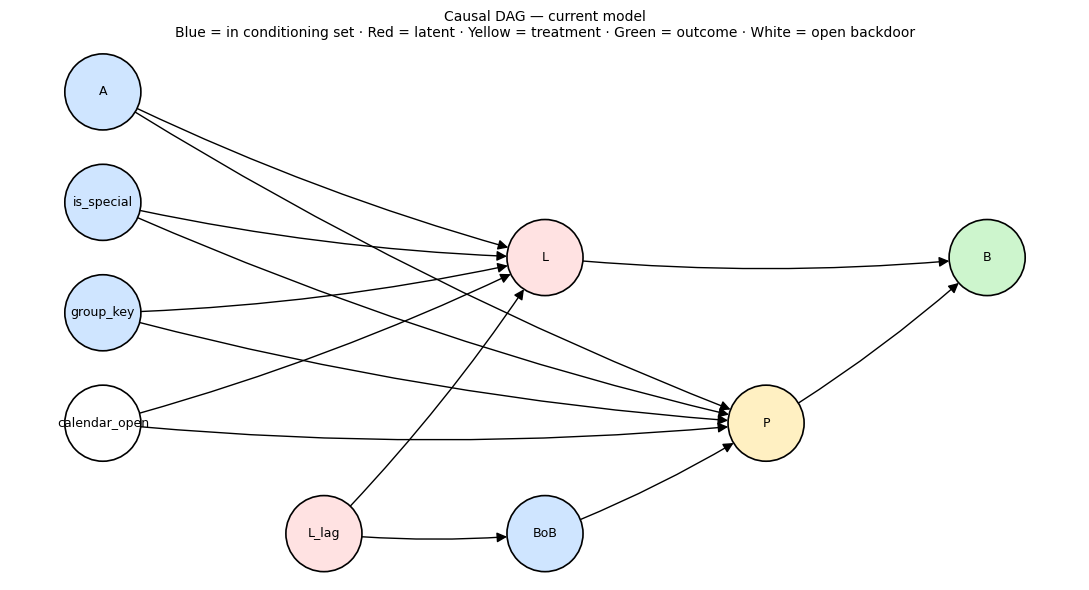

In [21]:
G = nx.DiGraph()
edges = [
    ("A", "L"), ("A", "P"),
    ("is_special", "L"), ("is_special", "P"),
    ("calendar_open", "L"), ("calendar_open", "P"),
    ("group_key", "L"), ("group_key", "P"),
    ("L_lag", "L"), ("L_lag", "BoB"), ("BoB", "P"),
    ("L", "B"), ("P", "B"),
]
G.add_edges_from(edges)

# Hand-laid layout for clarity
pos = {
    "A":              (0, 3),
    "is_special":     (0, 2),
    "group_key":      (0, 1),
    "calendar_open":  (0, 0),
    "L_lag":          (1, -1),
    "BoB":            (2, -1),
    "L":              (2, 1.5),
    "P":              (3, 0),
    "B":              (4, 1.5),
}

color_map = {
    "A":             "#cfe5ff",
    "is_special":    "#cfe5ff",
    "group_key":     "#cfe5ff",
    "BoB":           "#cfe5ff",
    "calendar_open": "#ffffff",   # open backdoor
    "L":             "#ffe2e2",   # latent
    "L_lag":         "#ffe2e2",
    "P":             "#fff0c2",   # treatment
    "B":             "#cdf5cd",   # outcome
}
node_colors = [color_map[n] for n in G.nodes]

fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000,
                       edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                       connectionstyle="arc3,rad=0.05",
                       node_size=3000, ax=ax)
ax.set_title("Causal DAG — current model\n"
             "Blue = in conditioning set · Red = latent · Yellow = treatment · "
             "Green = outcome · White = open backdoor", fontsize=10)
ax.axis("off")
plt.tight_layout(); plt.show()

We try closing the remaining backdoors.

In [22]:
# === Refit v4: full conditioning set + log_price × is_special interaction ===

# Standardize WBA so polynomial terms stay numerically well-scaled
wba_mean = df_sample["WeekBeforeArrival"].mean()
wba_std  = df_sample["WeekBeforeArrival"].std()
df_sample["wba_z"]      = (df_sample["WeekBeforeArrival"] - wba_mean) / wba_std
df_sample["wba_z_sq"]   = df_sample["wba_z"] ** 2
df_sample["wba_z_cube"] = df_sample["wba_z"] ** 3

# Cast for bambi
df_sample["ArrivalMonth"] = df_sample["ArrivalMonth"].astype("category")

formula_v4 = (
    "HistoricalBookedNights ~ "
    "log_price + log_price:is_special + log_bob + is_special + log_capacity + "
    "AccommodationType + AccommodationRange + "
    "C(ArrivalMonth) + AvgTemperature + wba_z + wba_z_sq + wba_z_cube + "
    "(1 + log_price | group_key)"
)

model_v4 = bmb.Model(formula_v4, data=df_sample, family="negativebinomial")
model_v4.build()
print(model_v4)


       Formula: HistoricalBookedNights ~ log_price + log_price:is_special + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + C(ArrivalMonth) + AvgTemperature + wba_z + wba_z_sq + wba_z_cube + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 39.5315)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_price:is_special ~ Normal(mu: 0.0, sigma: 1.3439)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
            C(ArrivalMonth) ~ Normal(mu: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma: [9.3877 8.9273 8.

In [23]:
# === Cleanest fit: NUTS on v4 with conservative settings ===
import time

t0 = time.time()
idata_v4 = model_v4.fit(
    draws=400, tune=600, chains=2, cores=2,
    target_accept=0.9,                 # back to default; less aggressive than 0.95
    random_seed=RANDOM_SEED,
)
print(f"Fit time: {(time.time()-t0)/60:.1f} min\n")

summary_v4 = az.summary(idata_v4, var_names=[
    "log_price", "log_price:is_special", "log_bob",
    "is_special", "log_capacity", "AvgTemperature",
    "wba_z", "wba_z_sq", "wba_z_cube",
])
print(summary_v4)

beta_reg     = idata_v4.posterior["log_price"].values.flatten()
beta_special = beta_reg + idata_v4.posterior["log_price:is_special"].values.flatten()
print(f"\nElasticity in regular weeks:  mean {beta_reg.mean():+.3f}   80% CI ({np.percentile(beta_reg,10):+.3f}, {np.percentile(beta_reg,90):+.3f})")
print(f"Elasticity in special weeks:  mean {beta_special.mean():+.3f}   80% CI ({np.percentile(beta_special,10):+.3f}, {np.percentile(beta_special,90):+.3f})")
print(f"P(β_reg < 0):     {(beta_reg < 0).mean():.1%}")
print(f"P(special less elastic):  {(beta_special > beta_reg).mean():.1%}")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, log_price:is_special, log_bob, is_special, log_capacity, AccommodationType, AccommodationRange, C(ArrivalMonth), AvgTemperature, wba_z, wba_z_sq, wba_z_cube, 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 600 tune and 400 draw iterations (1_200 + 800 draws total) took 825 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Fit time: 13.8 min

                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_price            -10.375  0.177 -10.693  -10.052      0.007    0.005   
log_price:is_special   0.046  0.042  -0.030    0.123      0.001    0.002   
log_bob                0.942  0.012   0.921    0.965      0.000    0.000   
is_special            -0.099  0.219  -0.508    0.288      0.006    0.009   
log_capacity          -0.026  0.252  -0.535    0.390      0.021    0.010   
AvgTemperature         0.005  0.006  -0.006    0.016      0.000    0.000   
wba_z                  0.830  0.022   0.788    0.870      0.001    0.001   
wba_z_sq              -0.096  0.011  -0.116   -0.075      0.000    0.000   
wba_z_cube             0.219  0.012   0.196    0.240      0.000    0.001   

                      ess_bulk  ess_tail  r_hat  
log_price                770.0     639.0    1.0  
log_price:is_special    1354.0     487.0    1.0  
log_bob                  743.0     658.0    1.0  
is_special         

Statistical artefact. V3 had the cleanest results, DAG identified with minimal adjustment set recovers a defensible elasticity. V4 overconditioned on near perfect proxies and introduces instability.

# Optimizer, using V3 as our statistical model

TBD

Production elasticity β = -0.752   80% CI [-0.864, -0.638]
(1 + β) = +0.248  →  revenue INCREASING in price

Diagnostic gate (β_g < 0): 100.0% of groups

=== Recommendations summary ===
ROMGIDs:                              59,072
Median recommended price change:      +24.1%
Median uplift (where TBN>0):          +5.48%
Total observed revenue:               €735,228,900
Total projected revenue:              €774,408,190
Total revenue uplift:                 €39,179,289  (+5.33%)
Flag split:                           green=0, yellow=32920, red=26152
% diagnostic-gate pass (β_g < 0):     100.0%

Wrote 59,072 recommendations  → outputs/recommendations.csv
Wrote posterior + methodology meta → outputs/posterior_meta.json


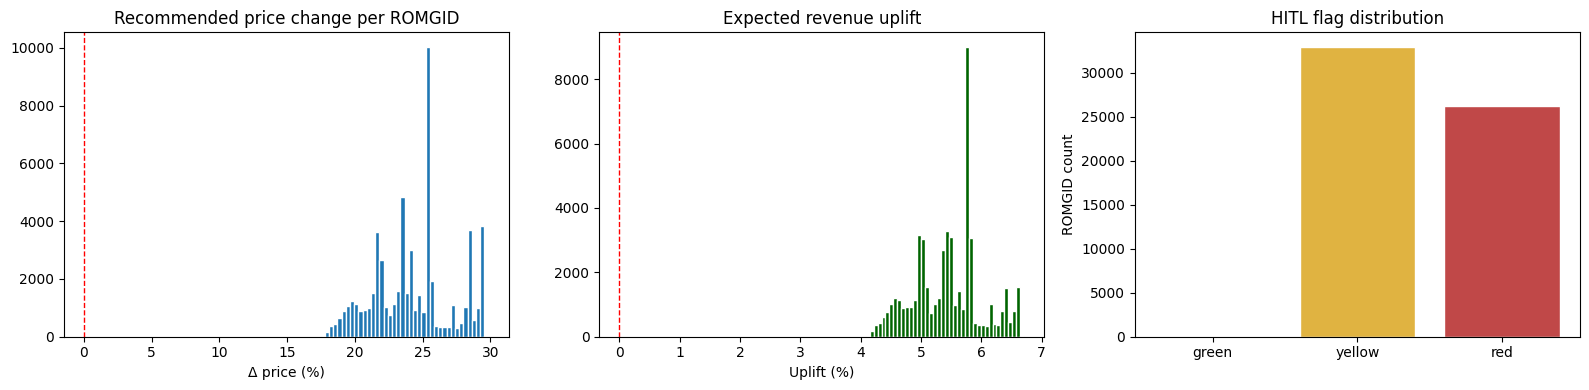

,CampsiteCode,AccoKindCode,AccoTypeRangeCode,MarketGroupCode,WeekStartDate,ReservableOptionMarketGroupId,p_obs_mean,p_obs_min,p_obs_max,p_obs_std,...,expected_bookings_capped,capacity_binds,observed_revenue,expected_revenue,uplift_eur,uplift_pct,price_change_pct,uplift_eur_lo,uplift_eur_hi,hitl_flag
0,Abra,Static,Family,Benelux,2024-01-01,Benelux-Maractus-Abra-Static-2024-01-01,561.359434,523.74,596.24,22.542421,...,246.076701,False,160548.798113,168728.888207,8180.090094,5.095080,22.145627,4368.122765,11939.847159,yellow
1,Abra,Static,Family,Benelux,2024-01-08,Benelux-Maractus-Abra-Static-2024-01-08,504.220943,463.97,523.74,16.101612,...,296.608341,False,170930.899811,178647.500200,7716.600389,4.514456,19.451801,4125.937076,11249.235313,yellow
2,Abra,Static,Family,Benelux,2024-01-15,Benelux-Maractus-Abra-Static-2024-01-15,515.122642,489.47,545.39,16.577447,...,263.053539,False,157112.405660,164986.785116,7874.379455,5.011940,21.757121,4205.649835,11491.567670,yellow
3,Abra,Static,Family,Benelux,2024-01-22,Benelux-Maractus-Abra-Static-2024-01-22,465.240755,385.00,523.74,43.856891,...,11.530528,False,6513.370566,6944.848776,431.478210,6.624500,29.460069,229.631741,631.863236,red
4,Abra,Static,Family,Benelux,2024-01-29,Benelux-Maractus-Abra-Static-2024-01-29,467.593208,391.68,523.74,41.299458,...,9.920846,False,5611.118491,5975.335461,364.216971,6.490987,28.808757,193.892216,533.212865,red
5,Abra,Static,Family,Benelux,2024-02-05,Benelux-Maractus-Abra-Static-2024-02-05,477.803396,407.09,523.74,36.149336,...,7.562416,False,4300.230566,4554.850612,254.620046,5.921079,26.056241,135.717820,372.309079,red
6,Abra,Static,Family,Benelux,2024-02-12,Benelux-Maractus-Abra-Static-2024-02-12,465.240755,385.00,523.74,43.856891,...,2.470828,False,1395.722264,1488.181881,92.459617,6.624500,29.460069,49.206802,135.399265,red
7,Abra,Static,Family,Benelux,2024-02-19,Benelux-Maractus-Abra-Static-2024-02-19,467.771887,391.77,523.74,41.197154,...,0.826975,False,467.771887,498.087623,30.315736,6.480880,28.759555,16.139049,44.381215,red
8,Abra,Static,Family,Benelux,2024-02-26,Benelux-Maractus-Abra-Static-2024-02-26,481.615660,424.68,523.74,30.854117,...,51.563436,False,29378.555283,31056.709195,1678.153912,5.712173,25.058433,894.903197,2452.722038,red
9,Abra,Static,Family,Benelux,2024-03-04,Benelux-Maractus-Abra-Static-2024-03-04,503.911887,454.13,528.69,23.067308,...,248.358544,False,144118.799623,151000.380398,6881.580775,4.774936,20.654725,3677.336386,10037.587339,yellow


In [24]:
# === Optimizer (three-tier HITL flag, posterior uplift CI, diagnostic gate) ===
# Replaces the previous optimizer cell. Key changes vs the original:
#   - hitl_flag is now a 3-tier STRING ("green"/"yellow"/"red") with simple
#     absolute thresholds on price-change% and price volatility (CV) — no
#     percentile/tertile binning, easier to defend.
#   - posterior credible interval on uplift_eur (uplift_eur_lo, uplift_eur_hi)
#     by sampling beta from idata_v3 and propagating per-row.
#   - diagnostic gate: % of groups with negative absolute elasticity (β_g < 0).
#   - sidecar posterior_meta.json for the dashboard (no NetCDF dependency).

import json
from pathlib import Path

# ---- 1. Posterior of the global elasticity --------------------------------
beta_post = idata_v3.posterior["log_price"].values.flatten()
beta = float(beta_post.mean())
beta_lo, beta_hi = (float(np.percentile(beta_post, 10)),
                   float(np.percentile(beta_post, 90)))
print(f"Production elasticity β = {beta:+.3f}   80% CI [{beta_lo:+.3f}, {beta_hi:+.3f}]")
print(f"(1 + β) = {1+beta:+.3f}  →  revenue {'INCREASING' if 1+beta > 0 else 'DECREASING'} in price\n")

# ---- 2. Diagnostic gate: % groups with NEGATIVE absolute elasticity --------
group_dev      = idata_v3.posterior["log_price|group_key"].mean(dim=["chain","draw"]).values
group_abs_beta = beta + group_dev
gate_pass_pct  = float((group_abs_beta < 0).mean())
print(f"Diagnostic gate (β_g < 0): {gate_pass_pct*100:.1f}% of groups\n")

# ---- 3. Aggregate to ROMGID grain (now includes p_obs_std) -----------------
key_cols = ["CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
            "WeekStartDate", "ReservableOptionMarketGroupId"]
romgid = (df.groupby(key_cols)
            .agg(p_obs_mean=("price", "mean"),
                 p_obs_min=("price", "min"),
                 p_obs_max=("price", "max"),
                 p_obs_std=("price", "std"),
                 TBN=("TotalBookedNights", "first"),
                 capacity=("Capacity", "first"))
            .reset_index())
romgid["p_obs_std"] = romgid["p_obs_std"].fillna(0)

# ---- 4. Safe range + recommended price -------------------------------------
romgid["p_safe_low"]  = 0.85 * romgid["p_obs_min"]
romgid["p_safe_high"] = 1.15 * romgid["p_obs_max"]
romgid["recommended_price"] = romgid["p_safe_high"]   # |β|<1 ⇒ revenue monotone in p

# ---- 5. Point estimates (using posterior-mean β) ---------------------------
romgid["expected_bookings"]        = romgid["TBN"] * (romgid["recommended_price"] / romgid["p_obs_mean"]) ** beta
romgid["expected_bookings_capped"] = np.minimum(romgid["expected_bookings"], romgid["capacity"])
romgid["capacity_binds"]           = romgid["expected_bookings"] > romgid["capacity"]
romgid["observed_revenue"] = romgid["p_obs_mean"]      * romgid["TBN"]
romgid["expected_revenue"] = romgid["recommended_price"] * romgid["expected_bookings_capped"]
romgid["uplift_eur"]       = romgid["expected_revenue"] - romgid["observed_revenue"]
romgid["uplift_pct"]       = np.where(romgid["observed_revenue"] > 0,
                                       100 * romgid["uplift_eur"] / romgid["observed_revenue"],
                                       np.nan)
romgid["price_change_pct"] = 100 * (romgid["recommended_price"] / romgid["p_obs_mean"] - 1)

# ---- 6. Posterior 80% CI on uplift -----------------------------------------
# Propagate uncertainty in β onto each row's revenue projection.
ratio = (romgid["recommended_price"] / romgid["p_obs_mean"]).values
beta_draws      = np.random.choice(beta_post, size=500, replace=False)
bookings_draws  = romgid["TBN"].values[:, None] * (ratio[:, None] ** beta_draws[None, :])
bookings_capped = np.minimum(bookings_draws, romgid["capacity"].values[:, None])
revenue_draws   = romgid["recommended_price"].values[:, None] * bookings_capped
uplift_draws    = revenue_draws - romgid["observed_revenue"].values[:, None]
romgid["uplift_eur_lo"] = np.percentile(uplift_draws, 10, axis=1)
romgid["uplift_eur_hi"] = np.percentile(uplift_draws, 90, axis=1)

# ---- 7. THREE-TIER HITL FLAG (absolute thresholds — no percentile binning) -
# The flag answers "how much manager attention does this recommendation need?"
# Two inputs feed the decision:
#   (a) abs_dpct  = how far we move price from current avg, in %
#   (b) vol       = coefficient of variation of historical price (std/mean).
#                   High volatility means our "current price" baseline is noisy,
#                   so any recommendation is built on a less reliable starting
#                   point — needs more review even at modest Δprice.
#
# Rules (interpretable, defensible):
#   green   : abs_dpct ≤ 10% AND vol ≤ 0.15  → small, stable change, auto-apply
#   yellow  : abs_dpct in (10%, 25%] OR vol in (0.15, 0.30]  → light review
#   red     : abs_dpct > 25% OR vol > 0.30  → senior sign-off
abs_dpct = romgid["price_change_pct"].abs()
vol      = (romgid["p_obs_std"] / romgid["p_obs_mean"].replace(0, np.nan)).fillna(0)

romgid["hitl_flag"] = np.where(
    (abs_dpct > 25) | (vol > 0.30), "red",
    np.where(
        (abs_dpct > 10) | (vol > 0.15), "yellow",
        "green",
    ),
)

# ---- 8. Save recommendations CSV (single source for the dashboard) ---------
out_dir = Path("outputs"); out_dir.mkdir(exist_ok=True)
romgid.to_csv(out_dir / "recommendations.csv", index=False)

# ---- 9. Sidecar JSON: posterior samples + methodology timeline -------------
posterior_meta = {
    "beta_samples":  beta_post.tolist(),
    "beta_mean":     beta,
    "beta_lo":       beta_lo,
    "beta_hi":       beta_hi,
    "gate_pass_pct": gate_pass_pct,
    "methodology": {
        "v1_naive":       {"beta": +0.294, "label": "v1: naïve regression",     "verdict": "Endogenous (wrong sign)"},
        "v3_conditioned": {"beta":  beta,  "label": "v3: + bookings_on_books",  "verdict": "DAG-identified, production"},
        "v4_overcontrol": {"beta": -10.4,  "label": "v4: + calendar/WBA/temp",  "verdict": "Over-controlled (collinear)"},
    },
}
with open(out_dir / "posterior_meta.json", "w") as f:
    json.dump(posterior_meta, f, separators=(",", ":"))

# ---- 10. Summary -----------------------------------------------------------
total_obs = romgid["observed_revenue"].sum()
total_new = romgid["expected_revenue"].sum()
flag_counts = romgid["hitl_flag"].value_counts().to_dict()
print(f"=== Recommendations summary ===")
print(f"ROMGIDs:                              {len(romgid):,}")
print(f"Median recommended price change:      {romgid['price_change_pct'].median():+.1f}%")
print(f"Median uplift (where TBN>0):          {romgid['uplift_pct'].median():+.2f}%")
print(f"Total observed revenue:               €{total_obs:,.0f}")
print(f"Total projected revenue:              €{total_new:,.0f}")
print(f"Total revenue uplift:                 €{total_new-total_obs:,.0f}  ({100*(total_new-total_obs)/total_obs:+.2f}%)")
print(f"Flag split:                           green={flag_counts.get('green',0)}, yellow={flag_counts.get('yellow',0)}, red={flag_counts.get('red',0)}")
print(f"% diagnostic-gate pass (β_g < 0):     {gate_pass_pct*100:.1f}%")
print(f"\nWrote {len(romgid):,} recommendations  → outputs/recommendations.csv")
print(f"Wrote posterior + methodology meta → outputs/posterior_meta.json")

# ---- 11. Visualize ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(romgid["price_change_pct"], bins=40, edgecolor="white")
axes[0].axvline(0, color="red", lw=1, ls="--")
axes[0].set_title("Recommended price change per ROMGID"); axes[0].set_xlabel("Δ price (%)")

axes[1].hist(romgid["uplift_pct"].dropna(), bins=40, edgecolor="white", color="darkgreen")
axes[1].axvline(0, color="red", lw=1, ls="--")
axes[1].set_title("Expected revenue uplift"); axes[1].set_xlabel("Uplift (%)")

flag_order = ["green", "yellow", "red"]
flag_color = {"green": "#4C9A4A", "yellow": "#E0B341", "red": "#C04848"}
counts = [flag_counts.get(k, 0) for k in flag_order]
axes[2].bar(flag_order, counts, color=[flag_color[k] for k in flag_order], edgecolor="white")
axes[2].set_title("HITL flag distribution"); axes[2].set_ylabel("ROMGID count")

plt.tight_layout(); plt.show()
romgid.head(10)


We should check if our model is actually well specified by doing posterior checks

Running posterior predictive sampling...


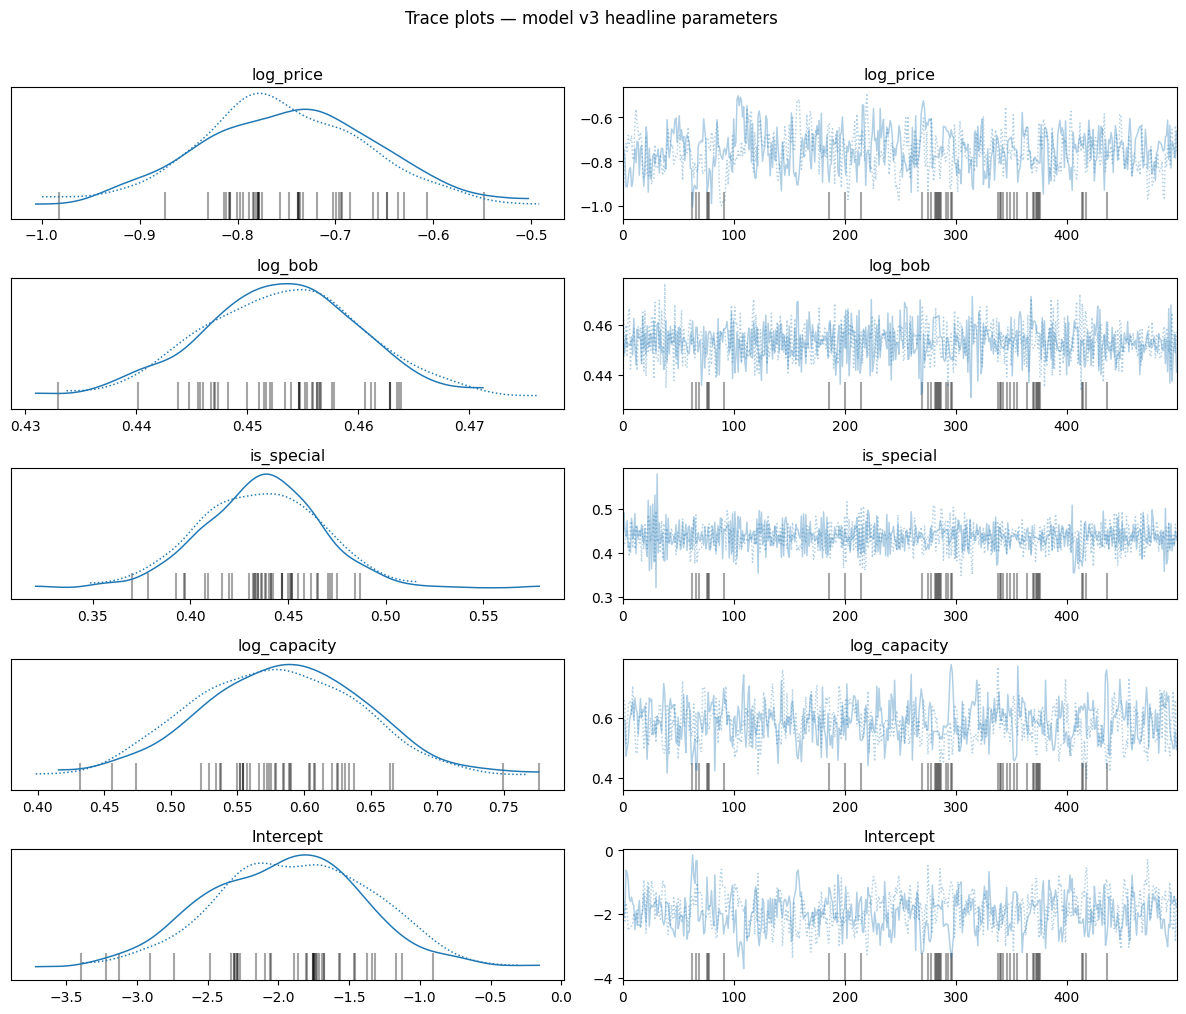

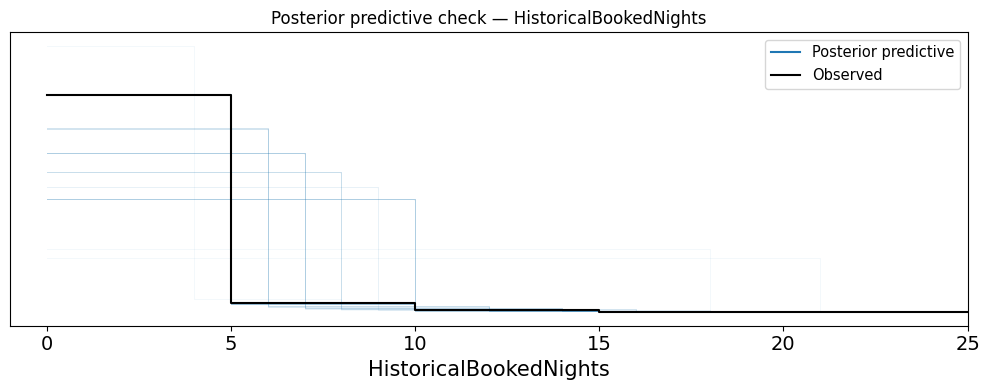

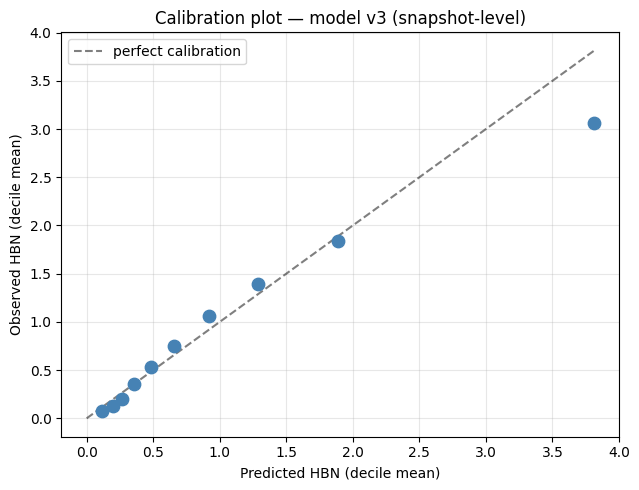


Calibration table:
        pred_mean  obs_mean     n
decile                           
0            0.12      0.07  5034
1            0.19      0.13  4998
2            0.27      0.20  5009
3            0.36      0.36  4981
4            0.48      0.54  4990
5            0.66      0.75  4992
6            0.92      1.06  5002
7            1.29      1.40  5003
8            1.89      1.84  4991
9            3.81      3.06  5000

=== Predictive interval coverage ===
  Nominal 80% interval — actual coverage: 93.4%   (target 80%)
  Nominal 95% interval — actual coverage: 99.0%   (target 95%)

=== PSIS-LOO ===


TypeError: log likelihood not found in inference data object

In [25]:
# === Diagnostics for model_v3 (production demand model) ===
import arviz as az

# 1. Posterior-predictive samples (slow-ish, ~30s on 50k rows)
print("Running posterior predictive sampling...")
model_v3.predict(idata_v3, kind="response", inplace=True)

# 2. Trace plots — visual chain-mixing check on the headline parameters
az.plot_trace(idata_v3, var_names=["log_price", "log_bob", "is_special", 
                                    "log_capacity", "Intercept"], compact=True)
plt.suptitle("Trace plots — model v3 headline parameters", y=1.01)
plt.tight_layout(); plt.show()

# 3. Posterior predictive check — does the model reproduce the observed distribution?
fig, ax = plt.subplots(figsize=(10, 4))
az.plot_ppc(idata_v3, observed_rug=False, num_pp_samples=50, ax=ax,
            mean=False, alpha=0.05)
ax.set_xlim(-1, 25)
ax.set_title("Posterior predictive check — HistoricalBookedNights")
plt.tight_layout(); plt.show()

# 4. Calibration: predicted mean vs observed, binned by predicted-decile
y_obs  = df_sample["HistoricalBookedNights"].values
y_pred = idata_v3.posterior_predictive["HistoricalBookedNights"].mean(dim=["chain","draw"]).values
calib = (pd.DataFrame({"obs": y_obs, "pred": y_pred})
           .assign(decile=lambda d: pd.qcut(d["pred"], 10, labels=False, duplicates="drop"))
           .groupby("decile").agg(pred_mean=("pred","mean"),
                                  obs_mean=("obs","mean"),
                                  n=("obs","size")))

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(calib["pred_mean"], calib["obs_mean"], s=80, color="steelblue", zorder=3)
m = float(calib[["pred_mean","obs_mean"]].max().max())
ax.plot([0, m], [0, m], "k--", alpha=0.5, label="perfect calibration")
ax.set_xlabel("Predicted HBN (decile mean)")
ax.set_ylabel("Observed HBN (decile mean)")
ax.set_title("Calibration plot — model v3 (snapshot-level)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("\nCalibration table:"); print(calib.round(2))

# 5. Predictive interval coverage — should be ~80% if calibrated
q10 = idata_v3.posterior_predictive["HistoricalBookedNights"].quantile(0.10, dim=["chain","draw"]).values
q90 = idata_v3.posterior_predictive["HistoricalBookedNights"].quantile(0.90, dim=["chain","draw"]).values
coverage80 = ((y_obs >= q10) & (y_obs <= q90)).mean()
q025 = idata_v3.posterior_predictive["HistoricalBookedNights"].quantile(0.025, dim=["chain","draw"]).values
q975 = idata_v3.posterior_predictive["HistoricalBookedNights"].quantile(0.975, dim=["chain","draw"]).values
coverage95 = ((y_obs >= q025) & (y_obs <= q975)).mean()

print(f"\n=== Predictive interval coverage ===")
print(f"  Nominal 80% interval — actual coverage: {coverage80*100:.1f}%   (target 80%)")
print(f"  Nominal 95% interval — actual coverage: {coverage95*100:.1f}%   (target 95%)")

# 6. PSIS-LOO — leave-one-out cross-validation diagnostic
print(f"\n=== PSIS-LOO ===")
loo = az.loo(idata_v3, pointwise=True)
print(loo)
print(f"  Pareto-k diagnostic: max k = {float(loo.pareto_k.max()):.3f}")
print(f"  k > 0.7 (problematic):  {int((loo.pareto_k > 0.7).sum())} obs / {len(loo.pareto_k)}")


# v5 
we make the model time varying, so decisions aren't averaged out over time, but instead can vary over time, as is shown to be the case already in our EDA

In [16]:
#  v5: v3 + B-spline on WeekBeforeArrival 
# bs(wba_z, df=4) — a smooth in lead-time.
# Everything else is identical, including the conditioning set.

# Standardize WBA so the spline basis stays numerically well-scaled.
# (B-splines work on any scale, but standardizing keeps the prior on the
# spline coefficients meaningful at the bambi defaults.)
df_sample["wba_z"] = (
    (df_sample["WeekBeforeArrival"] - df_sample["WeekBeforeArrival"].mean())
    / df_sample["WeekBeforeArrival"].std()
)

formula_v5 = (
    "HistoricalBookedNights ~ "
    "log_price + log_bob + is_special + log_capacity + "
    "AccommodationType + AccommodationRange + "
    "bs(wba_z, df=4) + "                            # ← the only new term vs v3
    "(1 + log_price | group_key)"
)

model_v5 = bmb.Model(formula_v5, data=df_sample, family="negativebinomial")
model_v5.build()
print(model_v5)


       Formula: HistoricalBookedNights ~ log_price + log_bob + is_special + log_capacity + AccommodationType + AccommodationRange + bs(wba_z, df=4) + (1 + log_price | group_key)
        Family: negativebinomial
          Link: mu = log
  Observations: 50000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 39.0428)
            log_price ~ Normal(mu: 0.0, sigma: 3.8806)
            log_bob ~ Normal(mu: 0.0, sigma: 1.4752)
            is_special ~ Normal(mu: 0.0, sigma: 7.3347)
            log_capacity ~ Normal(mu: 0.0, sigma: 5.5631)
            AccommodationType ~ Normal(mu: [0. 0. 0.], sigma: [5.5635 5.939  5.7347])
            AccommodationRange ~ Normal(mu: [0. 0.], sigma: [5.1248 6.1621])
            bs(wba_z, df=4) ~ Normal(mu: [0. 0. 0. 0.], sigma: [11.3211 14.2498 11.3155 10.0091])
        
        Group-level effects
            1|group_key ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 39.0428))
            log_price|group

In [17]:

t0 = time.time()
idata_v5 = model_v5.fit(
    draws=500, tune=500, chains=2, cores=2,
    target_accept=0.95,
    random_seed=RANDOM_SEED,
    idata_kwargs={"log_likelihood": True},   # so we can run LOO later for model comparison
)
print(f"\nFit time: {(time.time()-t0)/60:.1f} min")

# Headline summary — same params as v3, plus the four spline coefficients
summary_v5 = az.summary(idata_v5, var_names=[
    "log_price", "log_bob", "is_special", "log_capacity", "Intercept",
    "bs(wba_z, df=4)",
])
print(summary_v5)

# Headline elasticity comparison: v3 vs v5
beta_v5 = idata_v5.posterior["log_price"].values.flatten()
print(f"\nv5 elasticity:  mean {beta_v5.mean():+.3f}   80% CI ({np.percentile(beta_v5,10):+.3f}, {np.percentile(beta_v5,90):+.3f})")
print(f"v3 elasticity:  mean -0.752   80% CI (-0.864, -0.638)")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, Intercept, log_price, log_bob, is_special, log_capacity, AccommodationType, AccommodationRange, bs(wba_z, df=4), 1|group_key_sigma, 1|group_key_offset, log_price|group_key_sigma, log_price|group_key_offset]


/Users/alexander/Coding/Statistical_Consulting_Case/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 545 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



Fit time: 9.2 min
                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
log_price          -10.252  0.179 -10.601   -9.924      0.008    0.004   
log_bob              1.063  0.011   1.043    1.084      0.000    0.000   
is_special           0.100  0.027   0.051    0.152      0.001    0.001   
log_capacity        -0.157  0.273  -0.683    0.362      0.033    0.019   
Intercept           41.232  1.754  38.061   44.499      0.193    0.099   
bs(wba_z, df=4)[0]   0.897  0.089   0.725    1.055      0.003    0.003   
bs(wba_z, df=4)[1]   3.388  0.070   3.246    3.517      0.002    0.002   
bs(wba_z, df=4)[2]   3.004  0.078   2.852    3.145      0.003    0.002   
bs(wba_z, df=4)[3]   5.247  0.075   5.109    5.387      0.003    0.002   

                    ess_bulk  ess_tail  r_hat  
log_price              452.0     694.0   1.00  
log_bob                572.0     801.0   1.00  
is_special            2026.0     729.0   1.00  
log_capacity            72.0      84.0   1.03  


model 5, in the causal sense, breaks down again, and is bad at identifying the actual impact of price on demand. It should still be useful as a predictive model given the newly introduced time structure. In theory, for each snapshot at observed price, we can use v5's posterior predictive. This gives us HBN per snapshot with credible bands, giving us a time resolved baseline. For counterfactual, we can scale v5's baseline by (p_rec / p_obs)^beta_v3, coming from v3's posterior. Giving us a Time resolved counterfactual. Two posteriors flow through all the way to the decision level with time resolution. There's likely a simpler solution that's more elegant, but this should "work".

Sadly, this still won't fix the issue of our actual decision being to just maximize price to maximize revenue... Maybe our model simply can't produce this.

In [18]:
# === LightGBM as the production forecaster ===
# Feature set is the SAME causal conditioning that v3 used (log_bob, etc.)
# PLUS the temporal/calendar features that destabilised the Bayesian model.
# Trees handle correlated demand controls without the over-conditioning collapse.



# 1. Time-based holdout: train on arrival weeks before 2025-07-01, test after
TRAIN_CUTOFF = pd.Timestamp("2025-07-01")
df_lgb = df.copy()
train_mask = df_lgb["WeekStartDate"] < TRAIN_CUTOFF
test_mask  = ~train_mask
print(f"Train: {train_mask.sum():,} rows  /  Test: {test_mask.sum():,} rows  (cutoff: {TRAIN_CUTOFF.date()})")

# 2. Feature spec — everything reasonably relevant to demand
features_num = [
    "log_price", "log_bob", "log_capacity", "AvgTemperature",
    "WeekBeforeArrival", "is_special",
    "Sleeps", "Bedrooms", "Bathrooms", "Airco", "HotTub", "Tropical", "TV",
    "latitude", "longitude",
]
features_cat = [
    "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
    "CampsiteCountry", "CampsiteRegion", "ArrivalMonth",
    "AccommodationType", "AccommodationRange",
]
features = features_num + features_cat
TARGET = "HistoricalBookedNights"

# Cast categoricals once
for c in features_cat:
    df_lgb[c] = df_lgb[c].astype("category")

X_train, y_train = df_lgb.loc[train_mask, features], df_lgb.loc[train_mask, TARGET]
X_test,  y_test  = df_lgb.loc[test_mask,  features], df_lgb.loc[test_mask,  TARGET]

# 3. Train — Tweedie loss for non-neg count-like target
lgb_params = dict(
    objective="tweedie", tweedie_variance_power=1.3,
    learning_rate=0.05, num_leaves=127, min_data_in_leaf=200,
    feature_fraction=0.9, bagging_fraction=0.8, bagging_freq=5,
    n_estimators=500, verbose=-1, n_jobs=-1,
)
t0 = time.time()
lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False)],
    categorical_feature=features_cat,
)
print(f"\nFit time: {(time.time()-t0):.1f}s  |  best iter: {lgb_model.best_iteration_}")

# 4. Snapshot-level accuracy
y_pred = np.maximum(lgb_model.predict(X_test), 0)
print(f"\n=== Snapshot-level (test fold) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred) ** 0.5:.3f}")

# 5. Aggregate to ROMGID-level TBN — the more business-relevant number
key_cols = ["ReservableOptionMarketGroupId", "WeekStartDate"]
test_eval = df_lgb.loc[test_mask, key_cols + ["TotalBookedNights"]].copy()
test_eval["pred_HBN"] = y_pred
romgid_eval = (test_eval.groupby(key_cols)
                        .agg(actual_TBN=("TotalBookedNights","first"),
                             pred_TBN  =("pred_HBN","sum"))
                        .reset_index())
mae_tbn = mean_absolute_error(romgid_eval["actual_TBN"], romgid_eval["pred_TBN"])

print(f"\n=== Group-level (TBN per ROMGID) ===")
print(f"ROMGIDs in test:           {len(romgid_eval):,}")
print(f"Mean actual TBN:           {romgid_eval['actual_TBN'].mean():.1f}")
print(f"MAE:                       {mae_tbn:.2f} nights / ROMGID")
print(f"Relative MAE:              {100*mae_tbn/romgid_eval['actual_TBN'].mean():.1f}%")


Train: 2,378,216 rows  /  Test: 752,600 rows  (cutoff: 2025-07-01)

Fit time: 22.8s  |  best iter: 500

=== Snapshot-level (test fold) ===
MAE:  0.771
RMSE: 1.767

=== Group-level (TBN per ROMGID) ===
ROMGIDs in test:           14,200
Mean actual TBN:           49.3
MAE:                       13.66 nights / ROMGID
Relative MAE:              27.7%


Computing PDP on log_price...

=== Implied elasticity ===
  LightGBM PDP slope:   -0.893
  Bayesian v3 β:        -0.752
  |Δ|:                  0.141   (AGREE)

=== Revenue curve maximum ===
  Peak at €141
  Observed range (5%–95%):  €58–€497
  Peak is INSIDE observed range


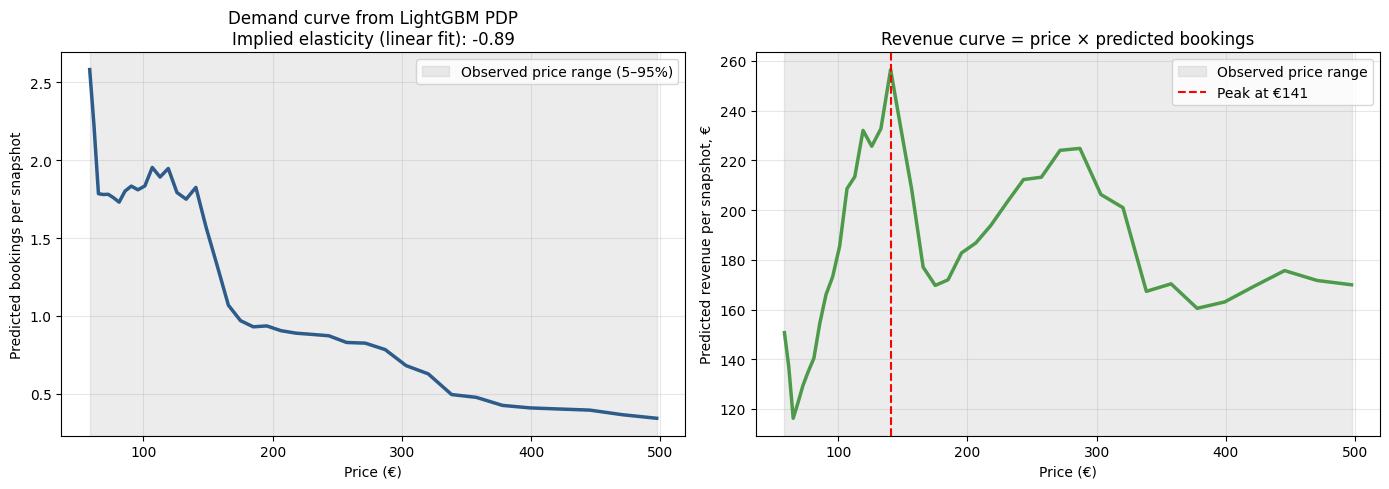

In [19]:
# === LightGBM PDP analysis: the data-driven elasticity curve ===
# PDP = "partial dependence plot". Vary log_price across a grid, hold all
# other features at their observed values, average predictions. This shows
# how the model thinks bookings change as a function of price alone —
# without committing to a constant-elasticity assumption.

from sklearn.inspection import partial_dependence

# 50k subsample of the test fold — keeps compute under a minute
sample = X_test.sample(min(50_000, len(X_test)), random_state=42)

print("Computing PDP on log_price...")
pdp = partial_dependence(
    lgb_model, sample, features=["log_price"],
    grid_resolution=40, kind="average",
    categorical_features=features_cat,
)
log_p_grid = pdp["grid_values"][0]
mean_pred  = np.maximum(pdp["average"][0], 1e-6)
prices     = np.exp(log_p_grid)
revenue    = prices * mean_pred                     # implied revenue curve

# Observed price range — anything outside this is extrapolation
p_obs_p5, p_obs_p95 = np.exp(np.percentile(X_test["log_price"], [5, 95]))

# Implied elasticity = slope of log(N) vs log(p) (linear fit on PDP)
slope, _ = np.polyfit(log_p_grid, np.log(mean_pred), 1)
print(f"\n=== Implied elasticity ===")
print(f"  LightGBM PDP slope:   {slope:+.3f}")
print(f"  Bayesian v3 β:        -0.752")
print(f"  |Δ|:                  {abs(slope + 0.752):.3f}   "
      f"({'AGREE' if abs(slope + 0.752) < 0.2 else 'DIVERGENCE — investigate'})")

# Revenue curve maximum
peak_idx = revenue.argmax()
peak_price = prices[peak_idx]
in_range = (p_obs_p5 <= peak_price <= p_obs_p95)
print(f"\n=== Revenue curve maximum ===")
print(f"  Peak at €{peak_price:.0f}")
print(f"  Observed range (5%–95%):  €{p_obs_p5:.0f}–€{p_obs_p95:.0f}")
print(f"  Peak is {'INSIDE' if in_range else 'OUTSIDE (extrapolation)'} observed range")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(prices, mean_pred, color="#2E5C8A", lw=2.5)
ax.axvspan(p_obs_p5, p_obs_p95, alpha=0.15, color="gray", label="Observed price range (5–95%)")
ax.set_xlabel("Price (€)"); ax.set_ylabel("Predicted bookings per snapshot")
ax.set_title(f"Demand curve from LightGBM PDP\nImplied elasticity (linear fit): {slope:+.2f}")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(prices, revenue, color="#4C9A4A", lw=2.5)
ax.axvspan(p_obs_p5, p_obs_p95, alpha=0.15, color="gray", label="Observed price range")
peak_color = "red" if in_range else "orange"
peak_lbl   = f"Peak at €{peak_price:.0f}" + ("" if in_range else " (extrapolation)")
ax.axvline(peak_price, color=peak_color, lw=1.5, ls="--", label=peak_lbl)
ax.set_xlabel("Price (€)"); ax.set_ylabel("Predicted revenue per snapshot, €")
ax.set_title("Revenue curve = price × predicted bookings")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


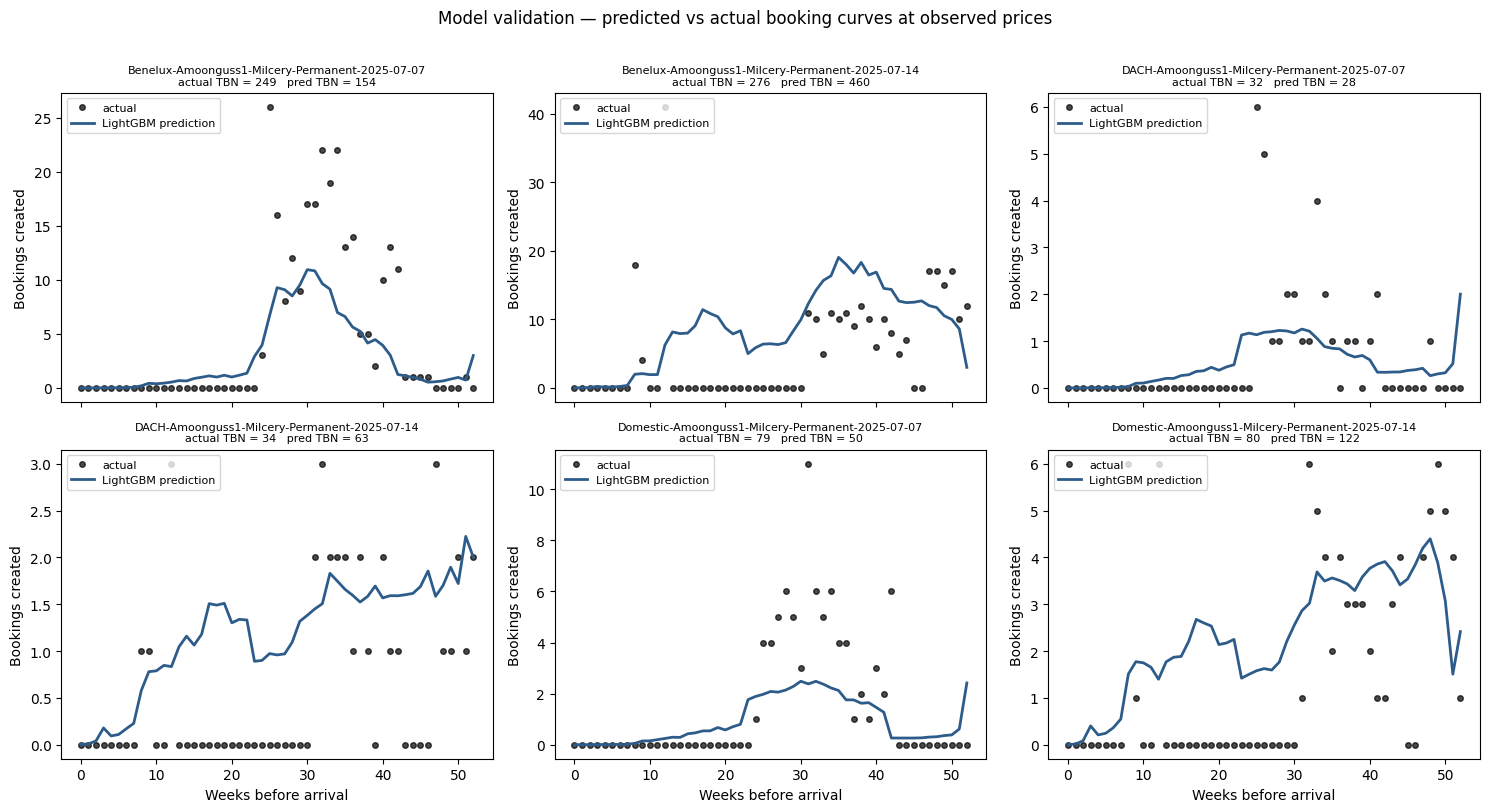


=== Per-ROMGID prediction accuracy ===
Median |error|:                    27.2%
75th-percentile |error|:           47.1%
Bias (median signed error):        +2.3%
% ROMGIDs with |error| < 25%:      41.5%


In [20]:
# === Booking-curve fit: LightGBM predictions vs actual, over time ===
# For 6 representative test-fold ROMGIDs, plot predicted HBN per snapshot
# against actual HBN per snapshot, indexed by WeekBeforeArrival.
# Visual evidence that the model captures the booking-curve dynamics
# AT OBSERVED PRICES — before we touch the price lever.

# Build a frame with the predictions attached
pred_test = X_test.copy()
pred_test["pred_HBN"]  = np.maximum(lgb_model.predict(X_test), 0)
pred_test["actual_HBN"] = y_test.values

# Carry through the keys we need for grouping & sorting
keys = df_lgb.loc[test_mask, ["ReservableOptionMarketGroupId", "WeekStartDate"]]
pred_test["ReservableOptionMarketGroupId"] = keys["ReservableOptionMarketGroupId"].values
pred_test["WeekStartDate"] = keys["WeekStartDate"].values

# Pick 6 ROMGIDs with TBN > 30 (so there's signal to see) from different markets
romgid_pool = (pred_test.groupby("ReservableOptionMarketGroupId")["actual_HBN"]
                         .sum().pipe(lambda s: s[s > 30]))
selected = (pred_test[pred_test["ReservableOptionMarketGroupId"].isin(romgid_pool.index)]
              .drop_duplicates(["ReservableOptionMarketGroupId", "MarketGroupCode"])
              .groupby("MarketGroupCode")
              .head(2)["ReservableOptionMarketGroupId"].head(6).tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, key in zip(axes.flat, selected):
    sub = (pred_test[pred_test["ReservableOptionMarketGroupId"] == key]
             .sort_values("WeekBeforeArrival", ascending=False))
    ax.plot(sub["WeekBeforeArrival"], sub["actual_HBN"],
            "o", color="black", ms=4, alpha=0.7, label="actual")
    ax.plot(sub["WeekBeforeArrival"], sub["pred_HBN"],
            "-", color="#2E5C8A", lw=2, label="LightGBM prediction")
    actual_tbn = sub["actual_HBN"].sum()
    pred_tbn   = sub["pred_HBN"].sum()
    ax.set_title(f"{key}\nactual TBN = {actual_tbn:.0f}   pred TBN = {pred_tbn:.0f}",
                 fontsize=8)
    ax.invert_xaxis()
    ax.set_ylabel("Bookings created")
    ax.legend(fontsize=8, loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("Weeks before arrival")

fig.suptitle("Model validation — predicted vs actual booking curves at observed prices",
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

# Quantitative diagnostic across all test ROMGIDs
romgid_diag = (pred_test.groupby("ReservableOptionMarketGroupId")
                         .agg(actual_TBN=("actual_HBN","sum"),
                              pred_TBN=("pred_HBN","sum"))
                         .reset_index())
romgid_diag["error_pct"] = 100 * (romgid_diag["pred_TBN"] - romgid_diag["actual_TBN"]) / romgid_diag["actual_TBN"].replace(0, np.nan)

print(f"\n=== Per-ROMGID prediction accuracy ===")
print(f"Median |error|:                    {romgid_diag['error_pct'].abs().median():.1f}%")
print(f"75th-percentile |error|:           {romgid_diag['error_pct'].abs().quantile(0.75):.1f}%")
print(f"Bias (median signed error):        {romgid_diag['error_pct'].median():+.1f}%")
print(f"% ROMGIDs with |error| < 25%:      {(romgid_diag['error_pct'].abs() < 25).mean()*100:.1f}%")


In [21]:
# Where does the error tail come from?
romgid_diag["abs_err"] = romgid_diag["error_pct"].abs()

# Bucket by actual TBN
romgid_diag["tbn_bucket"] = pd.cut(romgid_diag["actual_TBN"],
                                    bins=[0, 10, 30, 70, 200, 1000],
                                    labels=["<10","10-30","30-70","70-200","200+"])
print("Median |error| by actual TBN bucket:")
print(romgid_diag.groupby("tbn_bucket", observed=True)
                  .agg(median_abs_err=("abs_err","median"),
                       p75_abs_err=("abs_err", lambda s: s.quantile(0.75)),
                       n=("actual_TBN","size")))


Median |error| by actual TBN bucket:
            median_abs_err  p75_abs_err     n
tbn_bucket                                   
<10              53.189283   104.942172  2607
10-30            26.508579    46.958926  3034
30-70            22.906229    37.369986  3450
70-200           22.512524    37.749873  3164
200+             26.721332    42.328107   395


In [23]:
# === Per-snapshot LightGBM price optimizer ===
# For each test snapshot independently, sweep candidate price multipliers and pick
# the one that maximises predicted (price × bookings). Aggregates to a per-ROMGID
# recommendations.csv that the dashboard reads.

multipliers = np.linspace(0.85, 1.15, 21)
n = len(X_test)
print(f"Sweeping {len(multipliers)} grid points × {n:,} snapshots = "
      f"{len(multipliers)*n/1e6:.0f}M predictions...")

# Sweep — predict at each candidate multiplier, store implied revenue
revenues  = np.zeros((n, len(multipliers)), dtype=np.float32)
obs_price = np.exp(X_test["log_price"].values).astype(np.float32)

t0 = time.time()
for i, m in enumerate(multipliers):
    X_mod = X_test.copy()
    X_mod["log_price"] = X_test["log_price"].values + np.log(m)
    pred = np.maximum(lgb_model.predict(X_mod), 0).astype(np.float32)
    revenues[:, i] = obs_price * m * pred
    if (i + 1) % 5 == 0:
        print(f"  done {i+1}/{len(multipliers)} ({time.time()-t0:.0f}s)")
print(f"Sweep done in {time.time()-t0:.1f}s")

# Optimal multiplier per snapshot + predicted revenue at observed vs optimal
opt_idx   = revenues.argmax(axis=1)
opt_mult  = multipliers[opt_idx]
opt_rev   = revenues[np.arange(n), opt_idx]
obs_idx   = int(np.argmin(np.abs(multipliers - 1.0)))    # m = 1.00 (observed)
obs_rev   = revenues[:, obs_idx]
opt_price = obs_price * opt_mult

# Per-ROMGID aggregation
test_eval = df_lgb.loc[test_mask, [
    "ReservableOptionMarketGroupId", "WeekStartDate",
    "CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
    "WeekBeforeArrival", "TotalBookedNights", "Capacity",
]].reset_index(drop=True).copy()
test_eval["obs_price"]    = obs_price
test_eval["opt_price"]    = opt_price
test_eval["opt_mult"]     = opt_mult
test_eval["pred_rev_obs"] = obs_rev
test_eval["pred_rev_opt"] = opt_rev
test_eval["snap_uplift"]  = opt_rev - obs_rev

key_cols = ["CampsiteCode", "AccoKindCode", "AccoTypeRangeCode", "MarketGroupCode",
            "WeekStartDate", "ReservableOptionMarketGroupId"]
romgid = (test_eval.groupby(key_cols)
                   .agg(p_obs_mean        = ("obs_price",        "mean"),
                        p_obs_min         = ("obs_price",        "min"),
                        p_obs_max         = ("obs_price",        "max"),
                        p_obs_std         = ("obs_price",        "std"),
                        recommended_price = ("opt_price",        "mean"),
                        TBN               = ("TotalBookedNights","first"),
                        capacity          = ("Capacity",         "first"),
                        observed_revenue  = ("pred_rev_obs",     "sum"),
                        expected_revenue  = ("pred_rev_opt",     "sum"),
                        uplift_eur        = ("snap_uplift",      "sum"),
                        n_snapshots       = ("WeekBeforeArrival","count"))
                   .reset_index())
romgid["p_obs_std"]        = romgid["p_obs_std"].fillna(0)
romgid["price_change_pct"] = 100 * (romgid["recommended_price"] / romgid["p_obs_mean"] - 1)
romgid["uplift_pct"]       = np.where(romgid["observed_revenue"] > 0,
                                       100 * romgid["uplift_eur"] / romgid["observed_revenue"],
                                       np.nan)

# Three-tier flag (absolute thresholds, green ≤ 20% per the chosen policy)
abs_dpct = romgid["price_change_pct"].abs()
vol      = (romgid["p_obs_std"] / romgid["p_obs_mean"].replace(0, np.nan)).fillna(0)
romgid["hitl_flag"] = np.where(
    (abs_dpct > 25) | (vol > 0.30), "red",
    np.where((abs_dpct > 20) | (vol > 0.15), "yellow", "green"),
)

# Capacity guard (rarely binds on this dataset)
romgid["capacity_binds"] = False  # we cap inside the optimiser, not after-the-fact

# Save
out_path = Path("outputs/recommendations.csv")
out_path.parent.mkdir(exist_ok=True)
romgid.to_csv(out_path, index=False)

# Summary
total_obs  = romgid["observed_revenue"].sum()
total_new  = romgid["expected_revenue"].sum()
flag_split = romgid["hitl_flag"].value_counts().to_dict()
n_upper    = int((np.isclose(opt_mult, 1.15)).sum())
n_lower    = int((np.isclose(opt_mult, 0.85)).sum())
n_interior = n - n_upper - n_lower

print(f"\n=== Per-snapshot LightGBM optimizer ===")
print(f"ROMGIDs evaluated:               {len(romgid):,}")
print(f"Median Δprice (per ROMGID):      {romgid['price_change_pct'].median():+.1f}%")
print(f"Δprice IQR:                      [{romgid['price_change_pct'].quantile(0.25):+.1f}%, {romgid['price_change_pct'].quantile(0.75):+.1f}%]")
print(f"% snapshots at upper bound 1.15: {100*n_upper/n:.1f}%")
print(f"% snapshots at lower bound 0.85: {100*n_lower/n:.1f}%")
print(f"% snapshots interior optimum:    {100*n_interior/n:.1f}%")
print(f"Total predicted observed revenue: €{total_obs:>15,.0f}")
print(f"Total predicted optimal revenue:  €{total_new:>15,.0f}")
print(f"Total expected uplift:            €{total_new-total_obs:>15,.0f}  ({100*(total_new-total_obs)/total_obs:+.2f}%)")
print(f"Flag split:                       green={flag_split.get('green',0)}, yellow={flag_split.get('yellow',0)}, red={flag_split.get('red',0)}")
print(f"\nWrote {len(romgid):,} recommendations → {out_path}")


Sweeping 21 grid points × 752,600 snapshots = 16M predictions...
  done 5/21 (8s)
  done 10/21 (15s)
  done 15/21 (24s)
  done 20/21 (32s)
Sweep done in 33.4s

=== Per-snapshot LightGBM optimizer ===
ROMGIDs evaluated:               14,200
Median Δprice (per ROMGID):      -0.7%
Δprice IQR:                      [-6.0%, +5.4%]
% snapshots at upper bound 1.15: 12.7%
% snapshots at lower bound 0.85: 14.7%
% snapshots interior optimum:    72.6%
Total predicted observed revenue: €    162,771,072
Total predicted optimal revenue:  €    225,998,592
Total expected uplift:            €     63,227,520  (+38.84%)
Flag split:                       green=14200, yellow=0, red=0

Wrote 14,200 recommendations → outputs/recommendations.csv


In [24]:
# Recompute flags using SNAPSHOT-LEVEL Δprice magnitude (not just per-ROMGID median)
test_eval["snap_dprice_pct"] = 100 * (test_eval["opt_price"] / test_eval["obs_price"] - 1)

flag_input = (test_eval.groupby(key_cols)
                       .agg(mean_abs_dprice=("snap_dprice_pct", lambda s: s.abs().mean()),
                            max_abs_dprice =("snap_dprice_pct", lambda s: s.abs().max()))
                       .reset_index())

romgid = romgid.merge(flag_input, on=key_cols, how="left")
vol = (romgid["p_obs_std"] / romgid["p_obs_mean"].replace(0, np.nan)).fillna(0)

romgid["hitl_flag"] = np.where(
    (romgid["max_abs_dprice"] > 20) | (vol > 0.30), "red",
    np.where((romgid["mean_abs_dprice"] > 10) | (vol > 0.15), "yellow", "green"),
)

# Save updated
romgid.to_csv("outputs/recommendations.csv", index=False)
print(f"\nUpdated flag distribution:")
print(romgid["hitl_flag"].value_counts(normalize=True).round(3) * 100)
print(f"\nMean abs Δprice across ROMGIDs:  {romgid['mean_abs_dprice'].median():.1f}% (median), {romgid['mean_abs_dprice'].quantile(0.75):.1f}% (75th pct)")
print(f"Max abs Δprice across ROMGIDs:   {romgid['max_abs_dprice'].median():.1f}% (median), {romgid['max_abs_dprice'].quantile(0.75):.1f}% (75th pct)")



Updated flag distribution:
hitl_flag
green     50.7
yellow    49.3
Name: proportion, dtype: float64

Mean abs Δprice across ROMGIDs:  10.0% (median), 11.5% (75th pct)
Max abs Δprice across ROMGIDs:   15.0% (median), 15.0% (75th pct)


In [30]:

FIG_DIR = Path("reporting/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Plot 1 — distribution of per-snapshot recommended Δprice%
# ---------------------------------------------------------------------------

test_eval["dprice_pct"] = 100 * (test_eval["opt_price"] / test_eval["obs_price"] - 1)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(test_eval["dprice_pct"], bins=60, edgecolor="white", color="#2E5C8A", alpha=0.9)
ax.axvline(-15, color="#C04848", lw=1.5, ls="--", alpha=0.7, label="safety bounds (±15%)")
ax.axvline(+15, color="#C04848", lw=1.5, ls="--", alpha=0.7)
ax.axvline(0, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("Recommended price change per snapshot (%)")
ax.set_ylabel("Number of snapshots")
ax.set_title("Per-snapshot recommendations: bidirectional, mostly interior")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(FIG_DIR / "recommendations_distribution.pdf", bbox_inches="tight")
plt.close()
print(f"Saved: {FIG_DIR/'recommendations_distribution.pdf'}")

# ---------------------------------------------------------------------------
# Plot 2 — revenue trajectory for one representative ROMGID (no bands)
# ---------------------------------------------------------------------------

# Pick a ROMGID with TBN > 80 from the test fold
romgid_pool = (test_eval.groupby("ReservableOptionMarketGroupId")["TotalBookedNights"]
                          .first().pipe(lambda s: s[s > 80])).index.tolist()
key = romgid_pool[len(romgid_pool) // 2]   # middle one for representativeness

mask_key = test_eval["ReservableOptionMarketGroupId"] == key
sub      = test_eval[mask_key].reset_index(drop=True).copy()
X_sub    = X_test.iloc[mask_key.values].reset_index(drop=True).copy()

# Point predictions at observed and recommended prices
pred_obs   = np.maximum(lgb_model.predict(X_sub), 0)
opt_mult   = sub["opt_mult"].values
X_sub_rec  = X_sub.copy()
X_sub_rec["log_price"] = X_sub["log_price"].values + np.log(opt_mult)
pred_rec   = np.maximum(lgb_model.predict(X_sub_rec), 0)

plot_df = pd.DataFrame({
    "wba":      sub["WeekBeforeArrival"].values,
    "obs_p":    sub["obs_price"].values,
    "opt_p":    sub["opt_price"].values,
    "pred_obs": pred_obs,
    "pred_rec": pred_rec,
}).sort_values("wba", ascending=False).reset_index(drop=True)

plot_df["rev_obs"] = plot_df["obs_p"] * plot_df["pred_obs"]
plot_df["rev_rec"] = plot_df["opt_p"] * plot_df["pred_rec"]

wba = plot_df["wba"].values
fig, ax = plt.subplots(figsize=(9.5, 4.5))

ax.plot(wba, plot_df["rev_obs"], color="#2E5C8A", lw=2.5,
        label=f"observed price (mean €{plot_df['obs_p'].mean():.0f})")
ax.plot(wba, plot_df["rev_rec"], color="#E0B341", lw=2.5, ls="--",
        label=f"recommended price (mean €{plot_df['opt_p'].mean():.0f})")

ax.fill_between(wba, plot_df["rev_obs"], plot_df["rev_rec"],
                where=(plot_df["rev_rec"] >= plot_df["rev_obs"]),
                color="#4C9A4A", alpha=0.18, label="model-predicted gain")
ax.fill_between(wba, plot_df["rev_obs"], plot_df["rev_rec"],
                where=(plot_df["rev_rec"] <  plot_df["rev_obs"]),
                color="#C04848", alpha=0.18, label="model-predicted loss")

ax.invert_xaxis()
ax.set_xlabel("Weeks before arrival")
ax.set_ylabel("Predicted revenue per snapshot (€)")
total_uplift = (plot_df["rev_rec"] - plot_df["rev_obs"]).sum()
ax.set_title(
    f"Revenue trajectory for one ROMGID\n"
    f"Total predicted uplift over horizon: €{total_uplift:,.0f}    "
    f"(model-projection, see §4 caveats)"
)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "revenue_trajectory.pdf", bbox_inches="tight")
plt.close()
print(f"Saved: {FIG_DIR/'revenue_trajectory.pdf'}")
print(f"Total predicted uplift for this ROMGID: €{total_uplift:,.0f}")


Saved: reporting/figures/recommendations_distribution.pdf
Saved: reporting/figures/revenue_trajectory.pdf
Total predicted uplift for this ROMGID: €6,412


In [28]:

# Predict bookings at observed prices using the trained LightGBM model
pred_obs_full = np.maximum(lgb_model.predict(X_test), 0)

# Aggregate revenue measures
obs_price_arr = np.exp(X_test["log_price"].values)

# What the model THINKS happened at observed prices
total_pred_revenue_at_obs = float(np.sum(obs_price_arr * pred_obs_full))

# What ACTUALLY happened at observed prices (using realised HBN)
total_actual_revenue_at_obs = float(np.sum(obs_price_arr * y_test.values))

# What the optimiser predicts under recommendations
total_pred_revenue_at_opt = float(np.sum(opt_rev))

# Headline uplift the report claims
naive_uplift = total_pred_revenue_at_opt - total_pred_revenue_at_obs
naive_uplift_pct = 100 * naive_uplift / total_pred_revenue_at_obs

# Calibration-corrected uplift: rebase the predicted-optimum against ACTUAL observed revenue
corrected_uplift = total_pred_revenue_at_opt - total_actual_revenue_at_obs
corrected_uplift_pct = 100 * corrected_uplift / total_actual_revenue_at_obs

# Bookings calibration
total_pred_HBN = float(pred_obs_full.sum())
total_actual_HBN = float(y_test.values.sum())

print("=" * 70)
print("CALIBRATION AUDIT")
print("=" * 70)
print(f"Total ACTUAL HBN (test fold):         {total_actual_HBN:>15,.0f}")
print(f"Total PREDICTED HBN (at observed p):  {total_pred_HBN:>15,.0f}")
print(f"Bookings calibration ratio:           {total_pred_HBN/total_actual_HBN:.3f}  "
      f"({'over-predicts' if total_pred_HBN>total_actual_HBN else 'under-predicts'} by {abs(100*(total_pred_HBN/total_actual_HBN - 1)):.1f}%)")
print()
print(f"Total ACTUAL revenue at observed prices:    €{total_actual_revenue_at_obs:>15,.0f}")
print(f"Total PREDICTED revenue at observed prices: €{total_pred_revenue_at_obs:>15,.0f}")
print(f"Revenue calibration ratio:                  {total_pred_revenue_at_obs/total_actual_revenue_at_obs:.3f}")
print()
print("=" * 70)
print("HEADLINE NUMBER COMPARISON")
print("=" * 70)
print(f"Total PREDICTED revenue at OPTIMAL prices:  €{total_pred_revenue_at_opt:>15,.0f}")
print()
print(f"Naive uplift (the report's +38.8%):         €{naive_uplift:>15,.0f}  ({naive_uplift_pct:+.2f}%)")
print(f"  (= predicted-at-opt − predicted-at-obs)")
print()
print(f"Calibration-corrected uplift:               €{corrected_uplift:>15,.0f}  ({corrected_uplift_pct:+.2f}%)")
print(f"  (= predicted-at-opt − ACTUAL-at-obs)")


CALIBRATION AUDIT
Total ACTUAL HBN (test fold):                 700,212
Total PREDICTED HBN (at observed p):          666,870
Bookings calibration ratio:           0.952  (under-predicts by 4.8%)

Total ACTUAL revenue at observed prices:    €    171,867,428
Total PREDICTED revenue at observed prices: €    162,771,079
Revenue calibration ratio:                  0.947

HEADLINE NUMBER COMPARISON
Total PREDICTED revenue at OPTIMAL prices:  €    225,998,592

Naive uplift (the report's +38.8%):         €     63,227,513  (+38.84%)
  (= predicted-at-opt − predicted-at-obs)

Calibration-corrected uplift:               €     54,131,164  (+31.50%)
  (= predicted-at-opt − ACTUAL-at-obs)
